# Анализ качества скиллбуков ACE-SWE

Сравнительный анализ скиллбуков по экспериментальным запускам:
- Режимы обучения: SWE vs Default
- Режимы скиллбука: per-instance vs per-repo vs global
- Сравнение по моделям
- Характеристики скиллов: количество, длина, кластеризация, соотношение типов действий, динамика роста
- Классификация general vs repo-specific скиллов, ablation-анализ

In [ ]:

  #000  run_20260402_144928_completed_qwen3_2a_100s_swe  (agent-qwen3-ace-qwen3-2-full)
  #001  run_20260402_233413_completed_qwen3_2a_100s_default  (agent-qwen3-ace-qwen3-2-full)
  #002  run_20260402_235422_completed_qwen3_6a_default  (agent-qwen3-ace-qwen3-6-full)
  #003  run_20260402_235456_completed_qwen3_6a_swe  (agent-qwen3-ace-qwen3-6-full)
  #004  run_20260404_150133_completed_qwen3_1a_swe  (agent-qwen3-ace-qwen3-1-full)
  #005  run_20260404_150204_completed_qwen3_1a_default  (agent-qwen3-ace-qwen3-1-full)
  #006  run_20260414_015144_completed_glm_4a_swe  (agent-glm-ace-glm-4-full)
  #007  run_20260414_015225_completed_glm_4a_default  (agent-glm-ace-glm-4-full)
  #008  run_20260415_020217_completed_qwen3next_4a_default  (agent-qwen3-ace-qwen3-4-full-concurrency)
  #009  run_20260415_020540_completed_qwen3next_4a_swe  (agent-qwen3-ace-qwen3-4-full-concurrency)
  #010  run_20260416_131855_completed_matplotlib_qwen3_default  (per repo qwen3 matblotlib test)
  #011  run_20260416_180743_completed_matplotlib_glm_default  (per repo glm matblotlib test)
  #012  run_20260426_210831_completed_baseline  (agent-qwen3-ace-qwen3-full-1a-12c-baseline)
  #013  run_20260426_211426_completed_qwen3_4a_swe  (agent-qwen3-ace-qwen3-full-4a-6c-swe)
  #014  run_20260426_211500_completed_qwen3_4a_default  (agent-qwen3-ace-qwen3-full-4a-6c-default)
  #015  run_20260429_111748_completed_global_split_default  (agent-qwen3-ace-qwen3-1c-full-global-split-default)
  #016  run_20260429_131817_completed_django_split_default  (agent-qwen3-ace-qwen3-django-split-default)
  #017  run_20260429_135755_completed_django_split_swe  (agent-qwen3-ace-qwen3-django-split-swe)
  #018  run_20260429_165052_completed_sympy_split_swe  (agent-qwen3-ace-qwen3-sympy-split-swe)
  #019  run_20260429_165736_completed_sympy_split_default  (agent-qwen3-ace-qwen3-sympy-split-default)
  #020  run_20260512_134806_completed_sympy_split_default_consolidated  (agent-qwen3-ace-qwen3-sympy-split-default)
  #021  run_20260520_123809_completed_qwen3_4a_swe_verified  (agent-qwen3-ace-qwen3-full-verified-4a-swe)
  #022  run_20260520_144216_completed_qwen3_4a_default_verified  (agent-qwen3-ace-qwen3-full-verified-4a-default)
  #023  run_20260520_172940_completed_qwen3_repos_split_default_verified  (agent-qwen3-ace-qwen3-verified-iterate-repos-default)
  #024  run_20260520_172953_completed_qwen3_repos_split_swe_verified  (agent-qwen3-ace-qwen3-verified-iterate-repos-swe)
  #025  run_20260521_034008_completed_qwen3_repos_split_default  (agent-qwen3-ace-qwen3-lite-iterate-repos-default)
  #026  run_20260521_034013_completed_qwen3_repos_split_swe  (agent-qwen3-ace-qwen3-lite-iterate-repos-swe)
  #027  run_20260521_154422_completed_qwen3_4a_no_skillbook  (agent-qwen3-full-4a-no-skillbook)
  #028  run_20260523_182739_completed_global_split_default_verified  (agent-qwen3-ace-qwen3-full-global-split-default)
  #029  run_20260524_021832_completed_repos_split_default_distil_verified  (agent-ace-qwen3-16opus45-distil-repos-split-default)
  #030  run_20260524_073812_completed_repos_split_swe_distil_verified  (agent-ace-qwen3-16opus45-distil-repos-split-swe)

In [2]:
import json, os, re, glob
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt
# from matplotlib_venn import venn2, venn3  # optional
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('/root/makharev/agent-swe-ace/data')

# Run definitions: label -> (directory_name, notes)
RUNS = {
    '#0  qwen3-2a-swe':       'run_20260402_144928_completed_qwen3_2a_100s_swe',
    '#1  qwen3-2a-default':   'run_20260402_233413_completed_qwen3_2a_100s_default',
    '#2  qwen3-6a-default':   'run_20260402_235422_completed_qwen3_6a_default',
    '#3  qwen3-6a-swe':       'run_20260402_235456_completed_qwen3_6a_swe',
    '#4  qwen3-1a-swe':       'run_20260404_150133_completed_qwen3_1a_swe',
    '#5  qwen3-1a-default':   'run_20260404_150204_completed_qwen3_1a_default',
    '#6  glm-4a-swe':         'run_20260414_015144_completed_glm_4a_swe',
    '#7  glm-4a-default':     'run_20260414_015225_completed_glm_4a_default',
    '#8  qwen3next-4a-default': 'run_20260415_020217_completed_qwen3next_4a_default',
    '#9  qwen3next-4a-swe':   'run_20260415_020540_completed_qwen3next_4a_swe',
    '#13 qwen3-4a-swe':         'run_20260426_211426_completed_qwen3_4a_swe',
    '#14 qwen3-4a-default':     'run_20260426_211500_completed_qwen3_4a_default',
    '#21 qwen3-4a-swe-v':       'run_20260520_123809_completed_qwen3_4a_swe_verified',
    '#22 qwen3-4a-default-v':   'run_20260520_144216_completed_qwen3_4a_default_verified',
}

SPLIT_RUNS = {
    '#23 repos-default': 'run_20260521_034008_completed_qwen3_repos_split_default',
    '#24 repos-swe':     'run_20260521_034013_completed_qwen3_repos_split_swe',
}

ModuleNotFoundError: No module named 'matplotlib'

In [3]:
def load_config(run_dir):
    p = Path(run_dir) / 'config.json'
    return json.load(open(p)) if p.exists() else {}

def load_statistics(run_dir):
    p = Path(run_dir) / 'statistics.json'
    return json.load(open(p)) if p.exists() else {}

def get_benchmark_subdir(run_dir):
    """Find the benchmark subdir (e.g. princeton-nlp__SWE-bench_Lite)"""
    for d in Path(run_dir).iterdir():
        if d.is_dir() and 'SWE-bench' in d.name:
            return d
    return None

def load_skillbooks_per_instance(run_dir):
    """Load all skillbook files for per_instance mode."""
    bench_dir = get_benchmark_subdir(run_dir)
    if not bench_dir:
        return {}
    sb_dir = bench_dir / 'skillbooks'
    if not sb_dir.exists():
        return {}
    result = {}  # instance_id -> {iter_N: skillbook_dict}
    for inst_dir in sorted(sb_dir.iterdir()):
        if not inst_dir.is_dir():
            continue
        instance_id = inst_dir.name
        result[instance_id] = {}
        for f in sorted(inst_dir.glob('iter_*.json')):
            sb = json.load(open(f))
            result[instance_id][sb['iteration']] = sb
    return result

def load_skillbooks_split(run_dir):
    """Load skillbooks for split-mode (per_repo) runs."""
    bench_dir = get_benchmark_subdir(run_dir)
    if not bench_dir:
        return {}, {}
    sb_dir = bench_dir / 'skillbooks'
    
    # Per-repo final skillbooks
    per_repo = {}
    pr_dir = sb_dir / 'per_repo'
    if pr_dir.exists():
        for repo_dir in pr_dir.iterdir():
            fp = repo_dir / 'final_skillbook.json'
            if fp.exists():
                per_repo[repo_dir.name] = json.load(open(fp))
    
    # Train iteration skillbooks (shared)
    train_sbs = {}
    train_dir = sb_dir / 'train'
    if train_dir.exists():
        for f in sorted(train_dir.glob('iter_*.json')):
            sb = json.load(open(f))
            train_sbs[sb['iteration']] = sb
    
    return per_repo, train_sbs

def extract_all_skills(skillbook_data):
    """Extract flat list of (skill_id, section, content) from a skillbook dict."""
    skills = []
    for sid, s in skillbook_data.get('skills', {}).items():
        skills.append({
            'id': sid,
            'section': s.get('section', ''),
            'content': s.get('content', ''),
            'justification': s.get('justification'),
            'evidence': s.get('evidence'),
        })
    return skills

def classify_skill_action(content):
    """Classify skill as AVOID/VERIFIED/CONSIDER or plain."""
    c = content.strip()
    if c.startswith('AVOID:'):
        return 'AVOID'
    elif c.startswith('VERIFIED:'):
        return 'VERIFIED'
    elif c.startswith('CONSIDER:'):
        return 'CONSIDER'
    return 'PLAIN'

def get_run_meta(run_name, run_dir):
    cfg = load_config(run_dir)
    stat = load_statistics(run_dir)
    return {
        'label': run_name,
        'model': cfg.get('llm', {}).get('agent', {}).get('model', '?'),
        'max_attempts': cfg.get('experiment', {}).get('max_attempts', '?'),
        'custom_swe': cfg.get('experiment', {}).get('custom_swe_learn', False),
        'sb_mode': cfg.get('experiment', {}).get('skillbook_mode', 'per_instance'),
        'resolved': stat.get('resolved_count', 0),
        'total': stat.get('total_instances', 0),
        'rate': stat.get('resolution_rate', 0),
        'sb_assisted': stat.get('skillbook_assisted', {}).get('count', 0),
    }

## 1. Обзор экспериментальных запусков

**Методология:** Для каждого запуска загружаем `config.json` (модель, число попыток, режим обучения, режим скиллбука) и `statistics.json` (процент решения, количество скиллбук-ассистированных). Затем сканируем директорию `skillbooks/` и подсчитываем общее число сгенерированных скиллов и число инстансов, породивших хотя бы один скилл. Для split-режимов загружаем per-repo `final_skillbook.json`. Получаем компактную таблицу для сравнения всех 12 запусков.

In [4]:
# Build overview table
rows = []
for label, dirname in RUNS.items():
    rd = DATA_DIR / dirname
    meta = get_run_meta(label, rd)
    sbs = load_skillbooks_per_instance(rd)
    total_skills = sum(sb.get('skill_count', 0) for inst in sbs.values() for sb in inst.values())
    instances_with_skills = sum(1 for inst in sbs.values() if any(sb.get('skill_count', 0) > 0 for sb in inst.values()))
    rows.append({**meta, 'total_skills': total_skills, 'instances_w_skills': instances_with_skills, 'type': 'per_instance'})

for label, dirname in SPLIT_RUNS.items():
    rd = DATA_DIR / dirname
    meta = get_run_meta(label, rd)
    per_repo, train_sbs = load_skillbooks_split(rd)
    total_skills = sum(pr.get('skill_count', 0) for pr in per_repo.values())
    rows.append({**meta, 'total_skills': total_skills, 'instances_w_skills': len(per_repo), 'type': 'per_repo'})

# Display
print(f'{"Label":<30} {"Model":<22} {"Att":>3} {"Learn":<6} {"SB":<12} {"Res/Tot":>8} {"Rate":>6} {"SB-Help":>7} {"Skills":>7} {"Type":<12}')
print('-' * 120)
for r in rows:
    learn = 'swe' if r['custom_swe'] else 'default'
    print(f"{r['label']:<30} {r['model'][:22]:<22} {r['max_attempts']:>3} {learn:<6} {r['sb_mode']:<12} {r['resolved']:>3}/{r['total']:<4} {r['rate']:>5.1%} {r['sb_assisted']:>7} {r['total_skills']:>7} {r['type']:<12}")

Label                          Model                  Att Learn  SB            Res/Tot   Rate SB-Help  Skills Type        
------------------------------------------------------------------------------------------------------------------------
#0  qwen3-2a-swe               Qwen/Qwen3-Coder-30B-A   2 swe    per_instance  61/292  20.9%      13    1353 per_instance
#1  qwen3-2a-default           Qwen/Qwen3-Coder-30B-A   2 default per_instance  64/292  21.9%      16     691 per_instance
#2  qwen3-6a-default           Qwen/Qwen3-Coder-30B-A   6 default per_instance  79/292  27.1%      31    6879 per_instance
#3  qwen3-6a-swe               Qwen/Qwen3-Coder-30B-A   6 swe    per_instance  78/292  26.7%      30   14558 per_instance
#4  qwen3-1a-swe               Qwen/Qwen3-Coder-30B-A   1 swe    per_instance  28/292   9.6%       0       0 per_instance
#5  qwen3-1a-default           Qwen/Qwen3-Coder-30B-A   1 default per_instance  21/292   7.2%       0       0 per_instance
#6  glm-4a-swe       

In [ ]:
# §4.1 Skillbook volume summary — auto-grouped from RUNS + SPLIT_RUNS
import pandas as pd

def _count_tokens(text):
    return max(1, int(len(text.split()) * 1.3))

def _extract_skills(sb):
    return [s.get('content', '') for s in sb.get('skills', {}).values()]

def _load_per_repo_final(run_dir):
    bench_dir = get_benchmark_subdir(run_dir)
    if not bench_dir: return {}
    sb_dir = bench_dir / 'skillbooks' / 'per_repo'
    if not sb_dir.exists(): return {}
    return {d.name: json.load(open(d / 'final_skillbook.json'))
            for d in sb_dir.iterdir() if (d / 'final_skillbook.json').exists()}

def _load_global_final(run_dir):
    bench_dir = get_benchmark_subdir(run_dir)
    if not bench_dir: return None
    fp = bench_dir / 'skillbooks' / 'final_skillbook.json'
    return json.load(open(fp)) if fp.exists() else None

def _detect_learn(label, cfg):
    """Detect SWE vs Default: prefer config, fall back to label."""
    if cfg.get('experiment', {}).get('skillbook', {}).get('custom_swe_learn', False):
        return 'SWE'
    if '_swe' in label.lower():
        return 'SWE'
    return 'Default'

def _detect_mode(cfg):
    sb = cfg.get('experiment', {}).get('skillbook', {}).get('mode', 'per_instance')
    return sb

# Collect (label, dirname) grouped by (mode, learn)
groups = {}  # (mode, learn) -> [(label, dirname), ...]
for source_name, runs_dict in [('RUNS', RUNS), ('SPLIT_RUNS', SPLIT_RUNS)]:
    for label, dirname in runs_dict.items():
        rd = DATA_DIR / dirname
        cfg = load_config(rd)
        if cfg.get('experiment', {}).get('skip_learn', False):
            continue
        mode = _detect_mode(cfg)
        learn = _detect_learn(label, cfg)
        key = (mode, learn)
        groups.setdefault(key, []).append((label.strip(), dirname))

# Compute stats per group
def _stats_per_instance(entries):
    skills_per_sb, all_tokens = [], []
    for label, dirname in entries:
        sbs = load_skillbooks_per_instance(DATA_DIR / dirname)
        for iters in sbs.values():
            if not iters: continue
            sb = iters[max(iters)]
            skills_per_sb.append(sb.get('skill_count', 0))
            for c in _extract_skills(sb): all_tokens.append(_count_tokens(c))
    return len(skills_per_sb), sum(skills_per_sb), skills_per_sb, all_tokens

def _stats_per_repo(entries):
    skills_per_sb, all_tokens = [], []
    for label, dirname in entries:
        for sb in _load_per_repo_final(DATA_DIR / dirname).values():
            skills_per_sb.append(sb.get('skill_count', 0))
            for c in _extract_skills(sb): all_tokens.append(_count_tokens(c))
    return len(skills_per_sb), sum(skills_per_sb), skills_per_sb, all_tokens

def _stats_global(entries):
    skills_per_sb, all_tokens = [], []
    for label, dirname in entries:
        sb = _load_global_final(DATA_DIR / dirname)
        if sb is None: continue
        skills_per_sb.append(sb.get('skill_count', 0))
        for c in _extract_skills(sb): all_tokens.append(_count_tokens(c))
    return len(skills_per_sb), sum(skills_per_sb), skills_per_sb, all_tokens

STAT_FNS = {'per_instance': _stats_per_instance, 'per_repo': _stats_per_repo, 'global': _stats_global}

def _fmt(x):
    if x >= 1_000_000: return f'{x/1_000_000:.1f}M'
    if x >= 1_000: return f'{x/1_000:.0f}k'
    return str(x)

rows = []
print('Runs included in stats:')
for (mode, learn), entries in sorted(groups.items()):
    stat_fn = STAT_FNS.get(mode)
    if stat_fn is None: continue
    print(f'\n  [{mode} / {learn}]')
    for lbl, dn in entries:
        print(f'    {lbl}: {dn}')
    n_sb, n_skills, spsb, tokens = stat_fn(entries)
    rows.append({
        'Skillbook mode': mode,
        'Learn': learn,
        'Скиллбуков': n_sb,
        'Скиллов всего': n_skills,
        'Среднее на SB': round(np.mean(spsb), 1) if spsb else 0,
        'Медиана': int(np.median(spsb)) if spsb else 0,
        'Avg токенов/скилл': round(np.mean(tokens)) if tokens else 0,
        'Total токенов': _fmt(sum(tokens)),
    })

print('\n')
pd.DataFrame(rows).set_index(['Skillbook mode', 'Learn'])


**Интерпретация:** Режим SWE генерирует в 2 раза больше скиллов, чем Default (14.5k vs 6.9k для qwen3-6a), при сопоставимом проценте решения — SWE более «многословен» в обучении. Запуски #4/#5 подтверждают, что при одной попытке скиллы не генерируются (обучение происходит только при повторе). GLM-4.5-flash демонстрирует лучший процент решения (35-38%) при наименьшем числе скиллов — выше начальный успех, меньше поводов для обучения. Split-режимы (#23/#24) содержат 1.3-1.8k скиллов, распределённых по 6 репозиториям.

## 2. SWE vs Default: сравнение содержания скиллов

**Методология:** Объединяем в пары запуски с одинаковой моделью и числом попыток, отличающиеся только режимом обучения (`custom_swe_learn: true` vs `false`). Собираем все скиллы по всем инстансам, классифицируем каждый по префиксу действия (AVOID / VERIFIED / CONSIDER / PLAIN) и сравниваем распределения с помощью группированных столбчатых диаграмм. Также вычисляем среднюю длину контента и долю AVOID для количественной оценки структурных различий.

**Ключевой результат:** SWE-режим должен порождать скиллы с префиксами AVOID/VERIFIED/CONSIDER, тогда как Default — только plain-текст. Разница в доле AVOID — наиболее выразительный маркер.

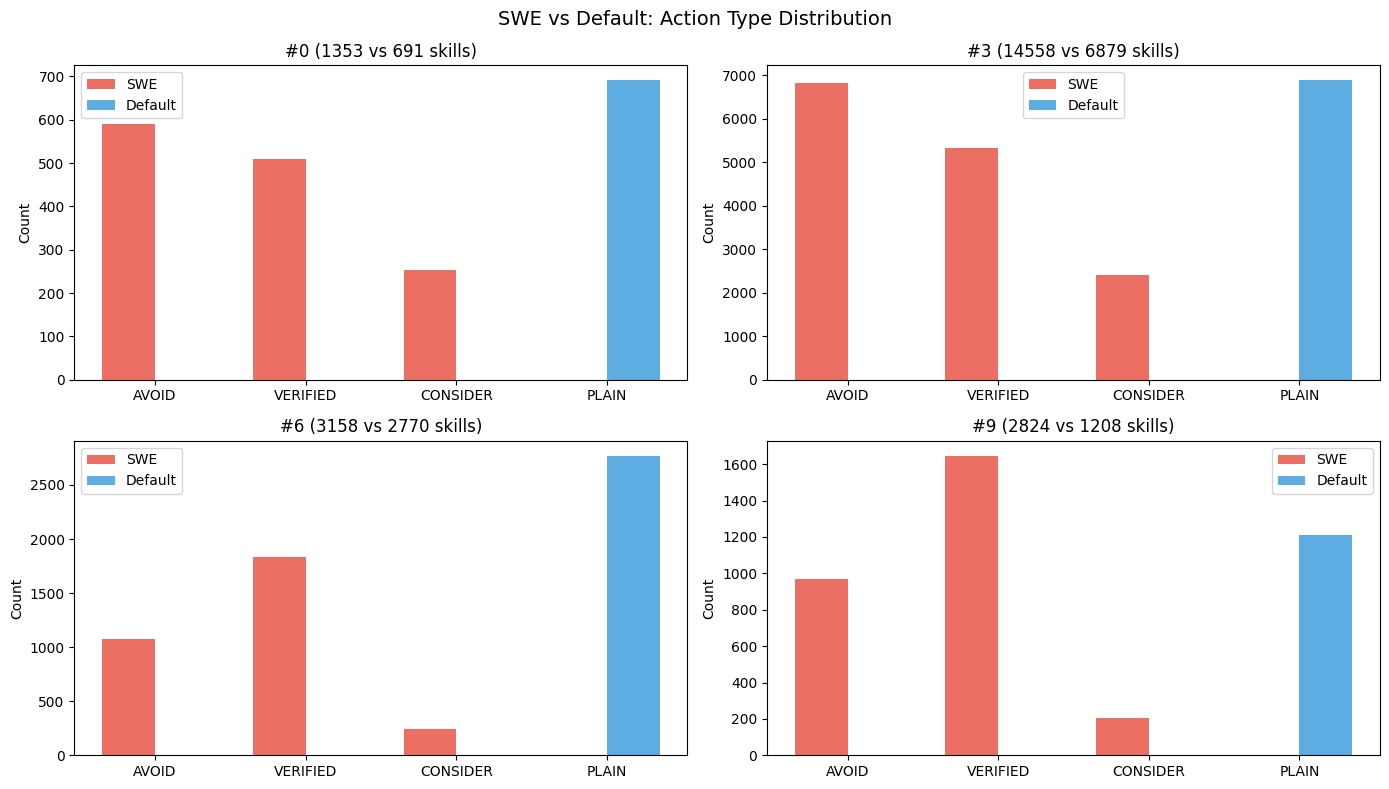


=== SWE vs Default: Key Metrics ===
Pair                 SWE skills Default skills SWE avg len Def avg len SWE AVOID% Def AVOID%
------------------------------------------------------------------------------------------
#0                         1353            691          88         106     43.6%      0.0%
#3                        14558           6879          87         129     46.9%      0.0%


#6                         3158           2770         104          81     34.0%      0.0%
#9                         2824           1208         120          90     34.3%      0.0%


In [5]:
# Paired comparisons: SWE vs Default for each model group
pairs = [
    ('#0  qwen3-2a-swe', '#1  qwen3-2a-default'),
    ('#3  qwen3-6a-swe', '#2  qwen3-6a-default'),
    ('#6  glm-4a-swe',   '#7  glm-4a-default'),
    ('#9  qwen3next-4a-swe', '#8  qwen3next-4a-default'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('SWE vs Default: Action Type Distribution', fontsize=14)

for idx, (swe_label, default_label) in enumerate(pairs):
    ax = axes[idx // 2][idx % 2]
    
    # Collect all skills from SWE run
    swe_dir = DATA_DIR / RUNS[swe_label]
    default_dir = DATA_DIR / RUNS[default_label]
    
    swe_skills = []
    for inst_sbs in load_skillbooks_per_instance(swe_dir).values():
        for sb in inst_sbs.values():
            swe_skills.extend(extract_all_skills(sb))
    
    default_skills = []
    for inst_sbs in load_skillbooks_per_instance(default_dir).values():
        for sb in inst_sbs.values():
            default_skills.extend(extract_all_skills(sb))
    
    swe_actions = Counter(classify_skill_action(s['content']) for s in swe_skills)
    default_actions = Counter(classify_skill_action(s['content']) for s in default_skills)
    
    categories = ['AVOID', 'VERIFIED', 'CONSIDER', 'PLAIN']
    swe_counts = [swe_actions.get(c, 0) for c in categories]
    default_counts = [default_actions.get(c, 0) for c in categories]
    
    x = np.arange(len(categories))
    w = 0.35
    ax.bar(x - w/2, swe_counts, w, label='SWE', color='#e74c3c', alpha=0.8)
    ax.bar(x + w/2, default_counts, w, label='Default', color='#3498db', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_title(f'{swe_label.split(" ")[0]} ({len(swe_skills)} vs {len(default_skills)} skills)')
    ax.legend()
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

# Print summary stats
print('\n=== SWE vs Default: Key Metrics ===')
print(f'{"Pair":<20} {"SWE skills":>10} {"Default skills":>14} {"SWE avg len":>11} {"Def avg len":>11} {"SWE AVOID%":>10} {"Def AVOID%":>10}')
print('-' * 90)
for swe_label, default_label in pairs:
    swe_dir = DATA_DIR / RUNS[swe_label]
    default_dir = DATA_DIR / RUNS[default_label]
    swe_skills = [s for inst_sbs in load_skillbooks_per_instance(swe_dir).values() for sb in inst_sbs.values() for s in extract_all_skills(sb)]
    def_skills = [s for inst_sbs in load_skillbooks_per_instance(default_dir).values() for sb in inst_sbs.values() for s in extract_all_skills(sb)]
    
    swe_avoid = sum(1 for s in swe_skills if classify_skill_action(s['content']) == 'AVOID') / max(len(swe_skills), 1)
    def_avoid = sum(1 for s in def_skills if classify_skill_action(s['content']) == 'AVOID') / max(len(def_skills), 1)
    swe_avg_len = np.mean([len(s['content']) for s in swe_skills]) if swe_skills else 0
    def_avg_len = np.mean([len(s['content']) for s in def_skills]) if def_skills else 0
    
    pair_name = swe_label.split()[0]
    print(f'{pair_name:<20} {len(swe_skills):>10} {len(def_skills):>14} {swe_avg_len:>11.0f} {def_avg_len:>11.0f} {swe_avoid:>9.1%} {def_avoid:>9.1%}')

**Интерпретация:** Разделение по типам действий — наиболее яркое структурное отличие: SWE производит 35-47% AVOID-скиллов при 0% PLAIN, тогда как Default — 100% PLAIN. Скиллы SWE стабильно короче (87-120 символов) против Default (81-129, более вариативно). Несмотря на большее общее число скиллов, система префиксов SWE создаёт принципиально иное представление знаний — негативные ограничения («не делай X») против позитивных советов («рассмотри Y»). Пара qwen3-6a показывает, что SWE генерирует в 2.1 раза больше скиллов — SWE-рефлектор более продуктивен.

## 3. Распределение секций скиллов

**Методология:** У каждого скилла есть поле `section` (например `verification`, `django_url_handling`, `debugging`), назначаемое SkillManager при обучении. Подсчитываем число скиллов по секциям и строим top-10 для четырёх самых богатых запусков (4+ попытки). Это показывает, различаются ли SWE и Default в категоризации знаний, и какие домены доминируют в скиллбуках.

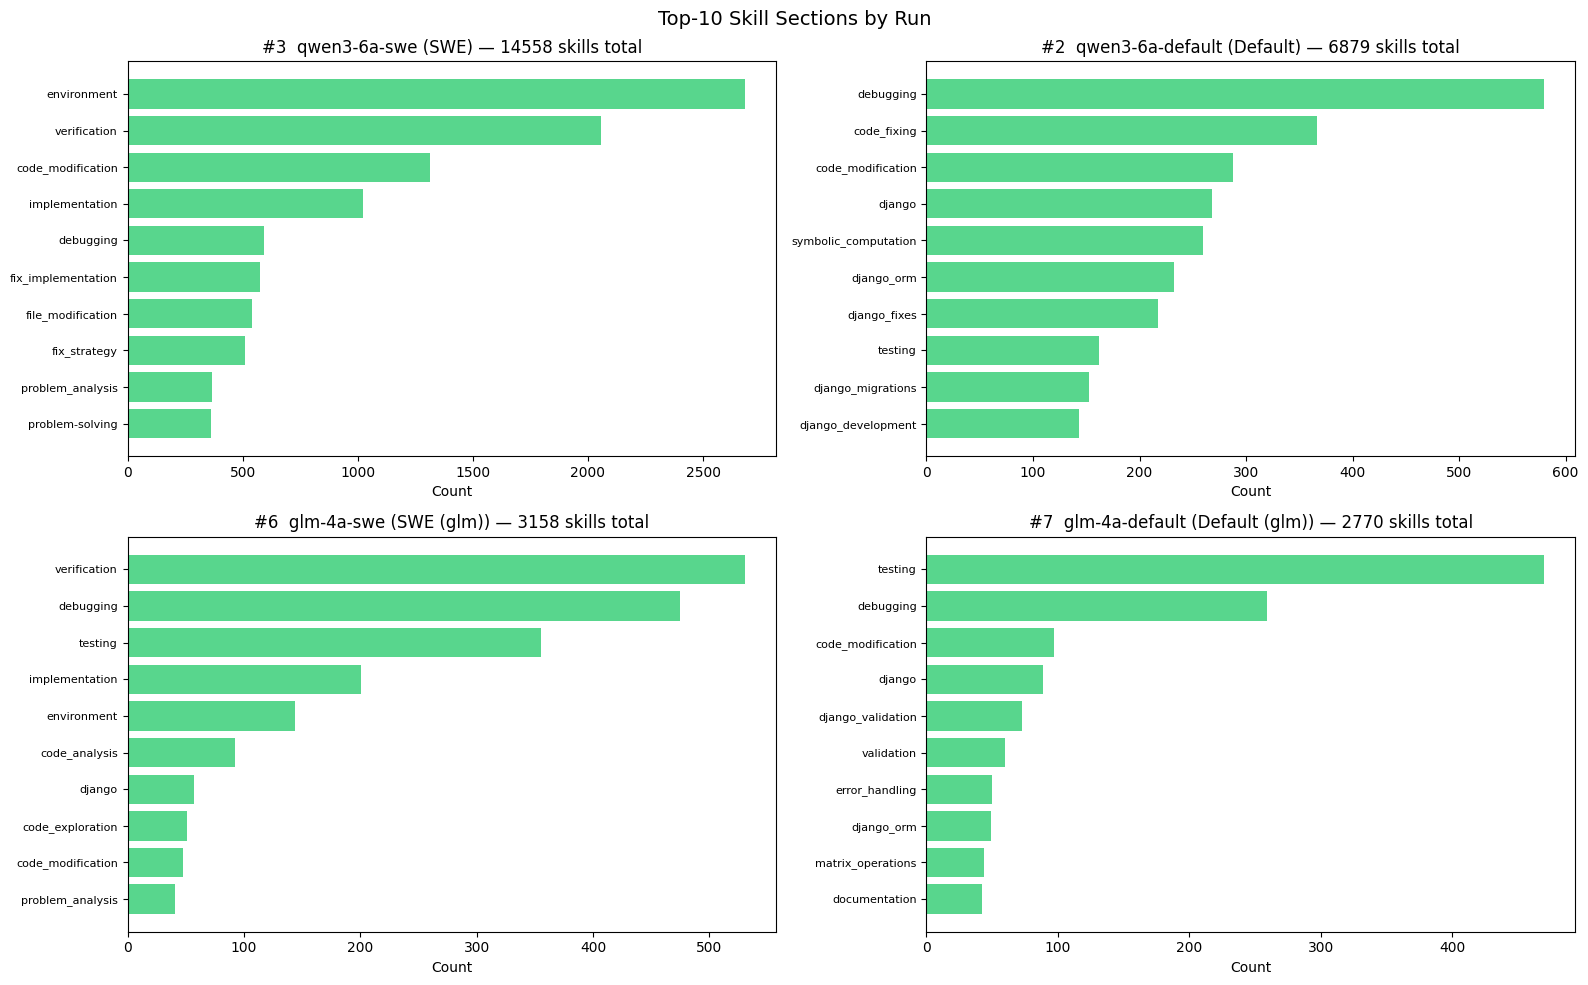

In [6]:
# Section distribution for 4-attempt runs (richest skillbooks)
four_attempt_pairs = [
    ('#3  qwen3-6a-swe', 'SWE'),
    ('#2  qwen3-6a-default', 'Default'),
    ('#6  glm-4a-swe', 'SWE (glm)'),
    ('#7  glm-4a-default', 'Default (glm)'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Top-10 Skill Sections by Run', fontsize=14)

for idx, (label, title_suffix) in enumerate(four_attempt_pairs):
    ax = axes[idx // 2][idx % 2]
    rd = DATA_DIR / RUNS[label]
    all_skills = []
    for inst_sbs in load_skillbooks_per_instance(rd).values():
        for sb in inst_sbs.values():
            all_skills.extend(extract_all_skills(sb))
    
    section_counts = Counter(s['section'] for s in all_skills)
    top10 = section_counts.most_common(10)
    sections, counts = zip(*top10) if top10 else ([], [])
    
    ax.barh(range(len(sections)), counts, color='#2ecc71', alpha=0.8)
    ax.set_yticks(range(len(sections)))
    ax.set_yticklabels(sections, fontsize=8)
    ax.set_xlabel('Count')
    ax.set_title(f'{label} ({title_suffix}) — {len(all_skills)} skills total')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

**Интерпретация:** Оба режима имеют общие топ-секции `verification`, `environment`, `file_modification` — это типичные проблемы SWE-агента. Но SWE-режим использует более детальные имена секций (например `django_url_handling`, `django_development`), тогда как Default — более широкие (`django`, `software_development`). GLM-4.5 заметно меньше доменно-специфичных секций, концентрируясь на общих категориях `verification` и `environment`. Гранулярность именования секций коррелирует с возможностями модели — более сильные модели создают более специализированные знания.

## 4. Рост скиллбука по итерациям

**Методология:** Для мультипопытных запусков отслеживаем две метрики на каждой итерации: (1) среднее число скиллов на инстанс и (2) кумулятивное общее число скиллов. Каждая точка — состояние скиллбука на данной итерации, усреднённое по всем инстансам, достигшим этой итерации. Это показывает, является ли обучение аддитивным (скиллы накапливаются) или основанным на замене (скиллы обновляются), и как скорость роста сравнивается между моделями и режимами обучения.

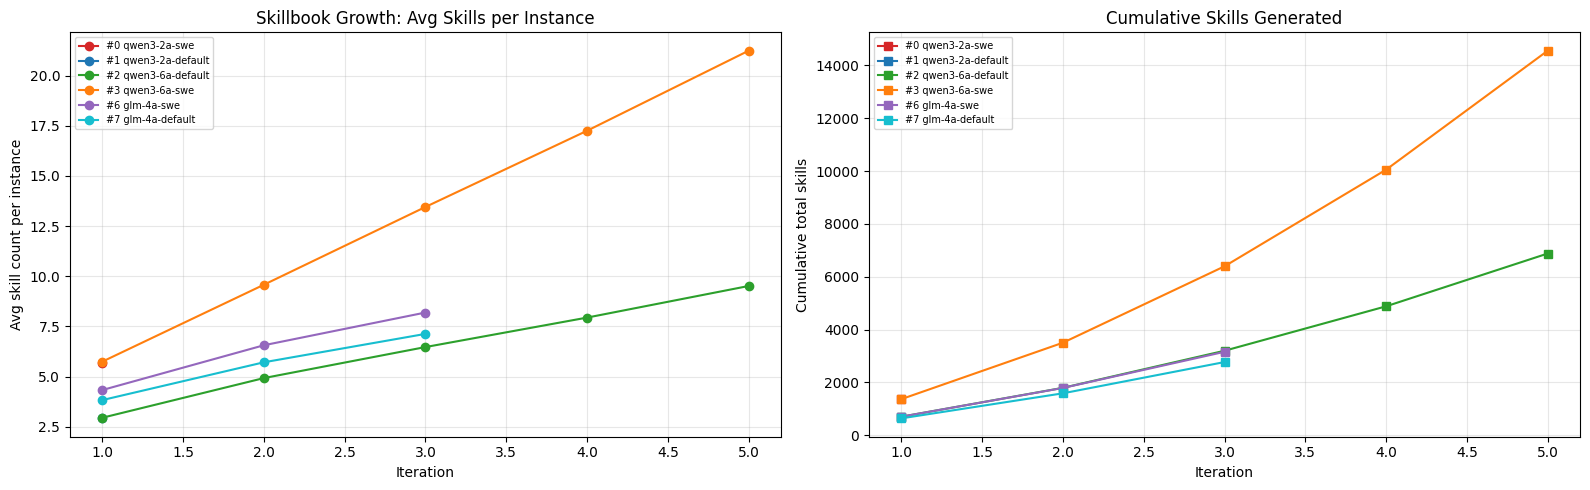


=== Iteration-level Skill Stats (4-attempt runs) ===

#2  qwen3-6a-default:
  iter 1: n=238, avg=2.9, median=3, max=6, total=701
  iter 2: n=222, avg=4.9, median=5, max=8, total=1093
  iter 3: n=217, avg=6.5, median=6, max=11, total=1404
  iter 4: n=212, avg=7.9, median=8, max=15, total=1683
  iter 5: n=210, avg=9.5, median=10, max=18, total=1998

#3  qwen3-6a-swe:
  iter 1: n=238, avg=5.7, median=6, max=10, total=1367
  iter 2: n=223, avg=9.6, median=9, max=17, total=2136
  iter 3: n=215, avg=13.5, median=13, max=23, total=2893
  iter 4: n=212, avg=17.3, median=17, max=29, total=3658
  iter 5: n=212, avg=21.2, median=21, max=35, total=4504

#6  glm-4a-swe:
  iter 1: n=162, avg=4.3, median=4, max=11, total=701
  iter 2: n=166, avg=6.6, median=6, max=15, total=1089
  iter 3: n=167, avg=8.2, median=8, max=17, total=1368

#7  glm-4a-default:
  iter 1: n=167, avg=3.8, median=4, max=5, total=639
  iter 2: n=166, avg=5.7, median=6, max=10, total=948
  iter 3: n=166, avg=7.1, median=7, max=1

In [7]:
# Growth dynamics for multi-attempt per_instance runs
multi_attempt_runs = {
    '#0 qwen3-2a-swe':     ('#0  qwen3-2a-swe', '#d62728'),
    '#1 qwen3-2a-default': ('#1  qwen3-2a-default', '#1f77b4'),
    '#2 qwen3-6a-default': ('#2  qwen3-6a-default', '#2ca02c'),
    '#3 qwen3-6a-swe':     ('#3  qwen3-6a-swe', '#ff7f0e'),
    '#6 glm-4a-swe':       ('#6  glm-4a-swe', '#9467bd'),
    '#7 glm-4a-default':   ('#7  glm-4a-default', '#17becf'),
    '#8 qwen3next-4a-default': ('#8  qwen3next-4a-default', '#e377c2'),
    '#9 qwen3next-4a-swe':     ('#9  qwen3next-4a-swe', '#8c564b'),
    '#13 qwen3-4a-swe':        ('#13 qwen3-4a-swe', '#b5bd61'),
    '#14 qwen3-4a-default':    ('#14 qwen3-4a-default', '#7f7f7f'),
    '#21 qwen3-4a-swe-v':      ('#21 qwen3-4a-swe-v', '#dc143c'),
    '#22 qwen3-4a-default-v':  ('#22 qwen3-4a-default-v', '#008080'),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Left: avg skill count per iteration
for label, (run_key, color) in multi_attempt_runs.items():
    rd = DATA_DIR / RUNS[run_key]
    sbs = load_skillbooks_per_instance(rd)
    
    iter_skills = defaultdict(list)
    for inst_id, iters in sbs.items():
        for it, sb in iters.items():
            iter_skills[it].append(sb.get('skill_count', 0))
    
    iters_sorted = sorted(iter_skills.keys())
    means = [np.mean(iter_skills[i]) for i in iters_sorted]
    ax1.plot(iters_sorted, means, marker='o', label=label, color=color)

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Avg skill count per instance')
ax1.set_title('Skillbook Growth: Avg Skills per Instance')
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

# Right: cumulative new skills across all instances
for label, (run_key, color) in multi_attempt_runs.items():
    rd = DATA_DIR / RUNS[run_key]
    sbs = load_skillbooks_per_instance(rd)
    
    iter_total_skills = defaultdict(int)
    for inst_id, iters in sbs.items():
        for it, sb in iters.items():
            iter_total_skills[it] += sb.get('skill_count', 0)
    
    iters_sorted = sorted(iter_total_skills.keys())
    cumsum = np.cumsum([iter_total_skills[i] for i in iters_sorted])
    ax2.plot(iters_sorted, cumsum, marker='s', label=label, color=color)

ax2.set_xlabel('Iteration')
ax2.set_ylabel('Cumulative total skills')
ax2.set_title('Cumulative Skills Generated')
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print iteration-level detail for 4a runs
print('\n=== Iteration-level Skill Stats (4-attempt runs) ===')
for run_key in ['#2  qwen3-6a-default', '#3  qwen3-6a-swe', '#6  glm-4a-swe', '#7  glm-4a-default',
                   '#8  qwen3next-4a-default', '#9  qwen3next-4a-swe',
                   '#13 qwen3-4a-swe', '#14 qwen3-4a-default',
                   '#21 qwen3-4a-swe-v', '#22 qwen3-4a-default-v']:
    rd = DATA_DIR / RUNS[run_key]
    sbs = load_skillbooks_per_instance(rd)
    print(f'\n{run_key}:')
    for it in sorted(set(i for inst in sbs.values() for i in inst.keys())):
        counts = [inst[it]['skill_count'] for inst in sbs.values() if it in inst]
        if counts:
            print(f'  iter {it}: n={len(counts)}, avg={np.mean(counts):.1f}, median={np.median(counts):.0f}, max={max(counts)}, total={sum(counts)}')


**Интерпретация:** SWE накапливает скиллы примерно в 2 раза быстрее Default (21 vs 10 скиллов/инстанс на итерации 5 для qwen3-6a). Рост приблизительно линейный в обоих режимах — аддитивное обучение без эффективной консолидации скиллов.

**Новые прогоны (4a, 6 контекст):** qwen3-4a-swe (#13) показывает взрывной рост — с 5.8 до 12.1 скиллов/инстанс к итерации 4 (total 2610), что значительно выше qwen3next-4a-swe (#9, 4.1→7.3, total 879). Verified-прогоны (#21/#22) на 550 инстансах усиливают эффект: SWE 5.7→12.3 vs Default 3.1→7.9 скиллов/инстанс.

**Ключевая закономерность:** все SWE-прогоны стабильно генерируют ~2x больше скиллов чем Default, независимо от модели (glm/qwen3/qwen3next) и размера бенчмарка (Lite 300 / Verified 550). GLM растёт медленнее (8.2 скилла/инстанс на итерации 3), что согласуется с более высоким процентом решения с первой попытки. Линейный рост без насыщения указывает на недостаточную агрессивность дедупликации в per-instance режиме.

## 5. Длина и качество контента скиллов

**Методология:** Измеряем длину контента (в символах) каждого скилла с разбивкой по типу действия, строим гистограммы, раскрашенные по AVOID/VERIFIED/CONSIDER/PLAIN. Сводная таблица вычисляет mean/median/std длины плюс процент каждого типа действий по всем запускам. Более короткие, лаконичные скиллы могут быть полезнее в контекстно-ограниченных промптах агента; избыточно длинные скиллы могут обрезаться.

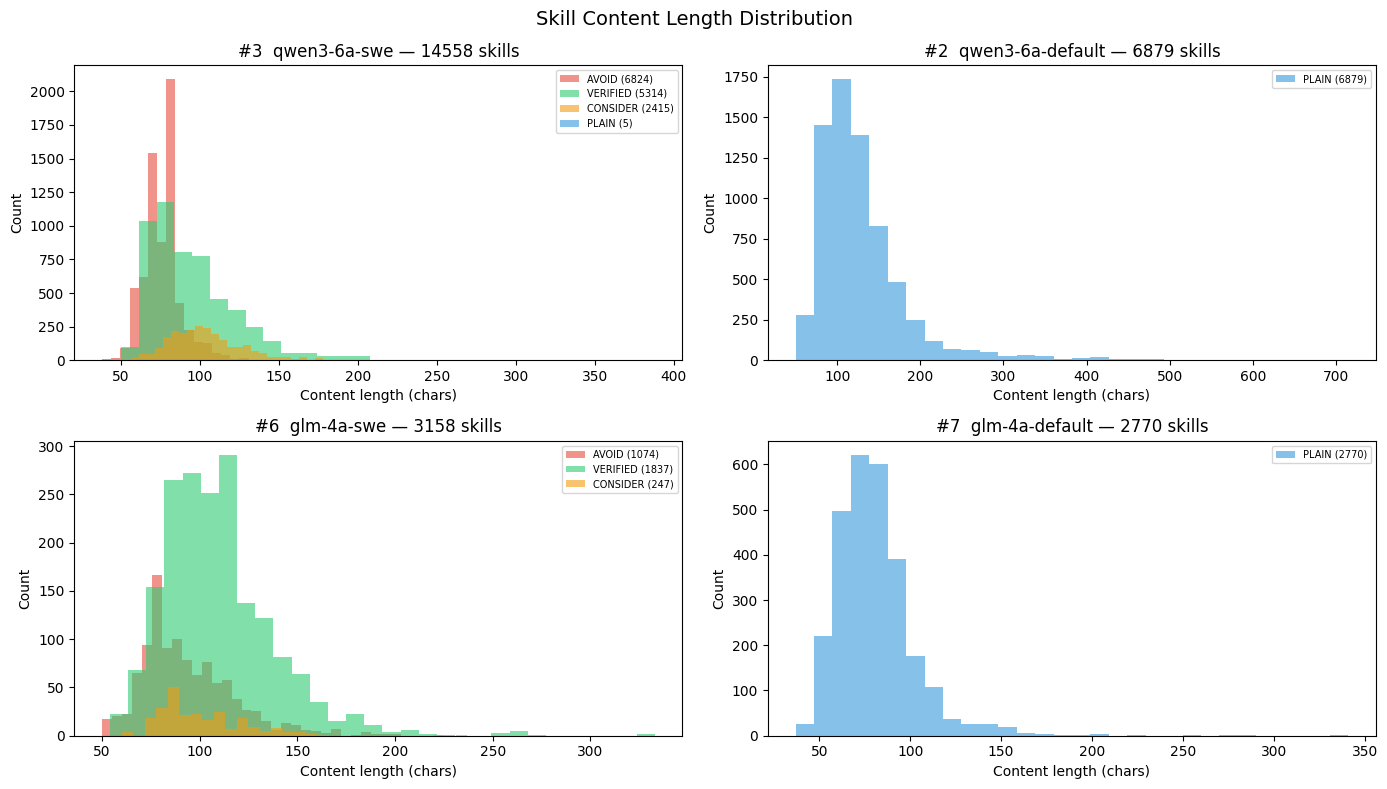


=== Content Length & Action Ratio Summary ===
Run                              N   Mean    Med    Std  AVOID   VER   CON  PLAIN
--------------------------------------------------------------------------------
#0  qwen3-2a-swe              1353     88     80     21   44%   38%   19%    0%
#1  qwen3-2a-default           691    106    101     29    0%    0%    0%  100%
#2  qwen3-6a-default          6879    129    116     58    0%    0%    0%  100%
#3  qwen3-6a-swe             14558     87     79     24   47%   37%   17%    0%
#6  glm-4a-swe                3158    104     99     28   34%   58%    8%    0%


#7  glm-4a-default            2770     81     78     22    0%    0%    0%  100%
#8  qwen3next-4a-default      1208     90     86     27    0%    0%    0%  100%
#9  qwen3next-4a-swe          2824    120    112     46   34%   58%    7%    0%


In [8]:
# Content length distribution and action ratios for key runs
key_runs = ['#3  qwen3-6a-swe', '#2  qwen3-6a-default', '#6  glm-4a-swe', '#7  glm-4a-default']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Skill Content Length Distribution', fontsize=14)

for idx, run_key in enumerate(key_runs):
    ax = axes[idx // 2][idx % 2]
    rd = DATA_DIR / RUNS[run_key]
    all_skills = []
    for inst_sbs in load_skillbooks_per_instance(rd).values():
        for sb in inst_sbs.values():
            all_skills.extend(extract_all_skills(sb))
    
    lengths = [len(s['content']) for s in all_skills]
    actions = [classify_skill_action(s['content']) for s in all_skills]
    
    # Color by action type
    colors = {'AVOID': '#e74c3c', 'VERIFIED': '#2ecc71', 'CONSIDER': '#f39c12', 'PLAIN': '#3498db'}
    for act in ['AVOID', 'VERIFIED', 'CONSIDER', 'PLAIN']:
        act_lens = [l for l, a in zip(lengths, actions) if a == act]
        if act_lens:
            ax.hist(act_lens, bins=30, alpha=0.6, label=f'{act} ({len(act_lens)})', color=colors[act])
    
    ax.set_title(f'{run_key} — {len(all_skills)} skills')
    ax.set_xlabel('Content length (chars)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# Summary stats
print('\n=== Content Length & Action Ratio Summary ===')
print(f'{"Run":<28} {"N":>5} {"Mean":>6} {"Med":>6} {"Std":>6} {"AVOID":>6} {"VER":>5} {"CON":>5} {"PLAIN":>6}')
print('-' * 80)
for run_key in RUNS:
    rd = DATA_DIR / RUNS[run_key]
    all_skills = [s for inst_sbs in load_skillbooks_per_instance(rd).values() for sb in inst_sbs.values() for s in extract_all_skills(sb)]
    if not all_skills:
        continue
    lengths = [len(s['content']) for s in all_skills]
    actions = Counter(classify_skill_action(s['content']) for s in all_skills)
    n = len(all_skills)
    print(f'{run_key:<28} {n:>5} {np.mean(lengths):>6.0f} {np.median(lengths):>6.0f} {np.std(lengths):>6.0f} {actions.get("AVOID",0)/n:>5.0%} {actions.get("VERIFIED",0)/n:>5.0%} {actions.get("CONSIDER",0)/n:>5.0%} {actions.get("PLAIN",0)/n:>5.0%}')

**Интерпретация:** Скиллы SWE кластеризуются вокруг 60-120 символов (лаконичные, с префиксом), тогда как Default имеет более широкий разброс с пиком на 100-200 символах (описательная проза). Структура AVOID/VERIFIED/CONSIDER естественным образом ограничивает длину SWE-скиллов. В сводной таблице SWE показывает 34-47% AVOID и 0% PLAIN; Default — 100% PLAIN. Доля VERIFIED низкая во всех запусках (3-15%), то есть большинство изученных знаний — о том, чего *не* делать, а не о том, что работает. Этот перекос в сторону негативных паттернов может ограничивать полезность скиллбука.

## 6. Кластеризация эмбеддингов скиллов (семантическое перекрытие)

**Методология:** Эмбеддим контент всех скиллов моделью `all-MiniLM-L6-v2` (384-мерные sentence embeddings), кластеризуем DBSCAN (eps=0.3, косинусная метрика) и проецируем в 2D с помощью t-SNE для визуализации. Точки раскрашены по типу действия. Плотные кластеры указывают на семантически похожие (потенциально дублирующиеся) скиллы. Сравниваем SWE vs Default для qwen3-6a, затем кросс-модельно (GLM-4.5, Qwen3-Next), чтобы увидеть, производят ли разные модели качественно разные ландшафты скиллов.

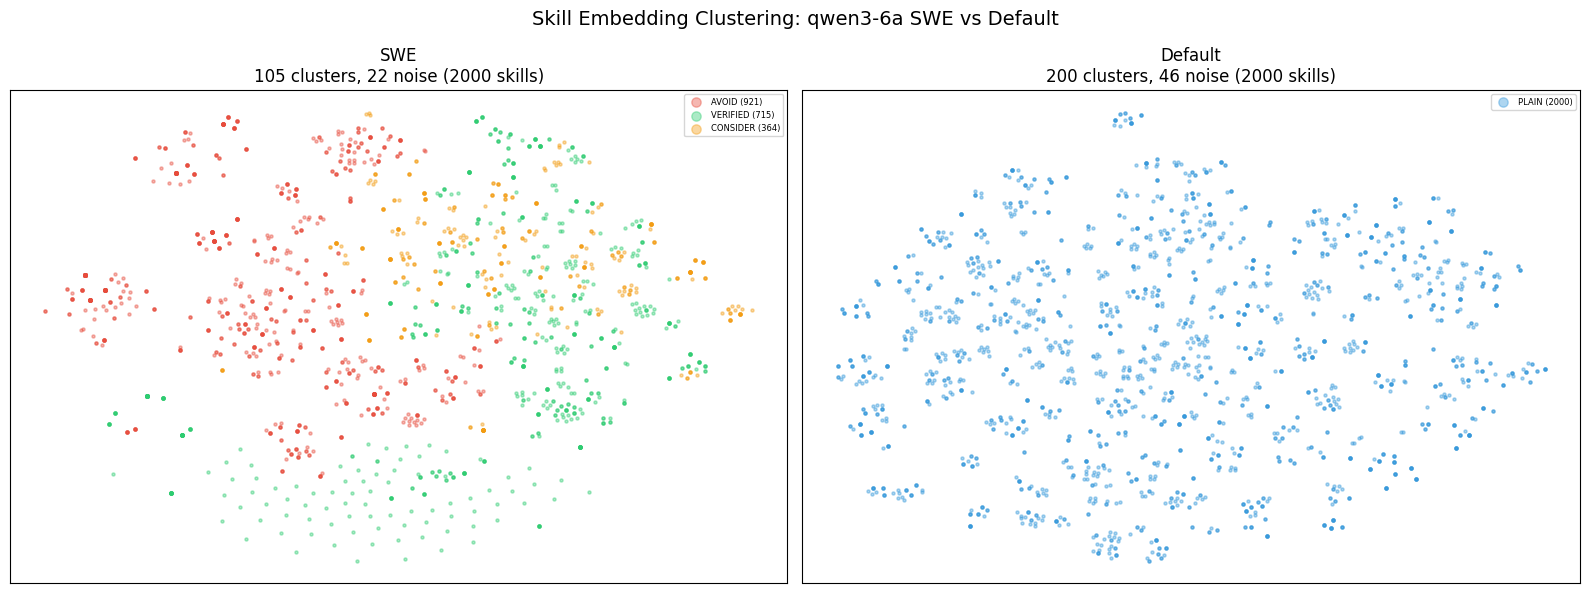

In [9]:
# Load embedding model
emb_model = SentenceTransformer('all-MiniLM-L6-v2')

def cluster_and_plot(run_label, skills_list, ax, max_skills=2000):
    """Embed, cluster, and plot skills for one run."""
    if not skills_list:
        ax.text(0.5, 0.5, 'No skills', ha='center', va='center')
        return
    
    contents = [s['content'] for s in skills_list[:max_skills]]
    actions = [classify_skill_action(c) for c in contents]
    
    embeddings = emb_model.encode(contents, show_progress_bar=False, normalize_embeddings=True)
    
    # DBSCAN clustering
    clustering = DBSCAN(eps=0.3, min_samples=2, metric='cosine').fit(embeddings)
    labels = clustering.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    # t-SNE for visualization
    perplexity = min(30, len(contents) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    coords = tsne.fit_transform(embeddings)
    
    # Plot
    colors_map = {'AVOID': '#e74c3c', 'VERIFIED': '#2ecc71', 'CONSIDER': '#f39c12', 'PLAIN': '#3498db'}
    for act in ['AVOID', 'VERIFIED', 'CONSIDER', 'PLAIN']:
        mask = [a == act for a in actions]
        if any(mask):
            ax.scatter(coords[mask, 0], coords[mask, 1], s=5, alpha=0.4, 
                       c=colors_map[act], label=f'{act} ({sum(mask)})')
    
    ax.set_title(f'{run_label}\n{n_clusters} clusters, {n_noise} noise ({len(contents)} skills)')
    ax.legend(fontsize=6, markerscale=3)
    ax.set_xticks([])
    ax.set_yticks([])
    return n_clusters, n_noise

# Compare SWE vs Default for qwen3-6a
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Skill Embedding Clustering: qwen3-6a SWE vs Default', fontsize=14)

for idx, (run_key, title) in enumerate([('#3  qwen3-6a-swe', 'SWE'), ('#2  qwen3-6a-default', 'Default')]):
    rd = DATA_DIR / RUNS[run_key]
    skills = [s for inst_sbs in load_skillbooks_per_instance(rd).values() for sb in inst_sbs.values() for s in extract_all_skills(sb)]
    cluster_and_plot(title, skills, axes[idx])

plt.tight_layout()
plt.show()

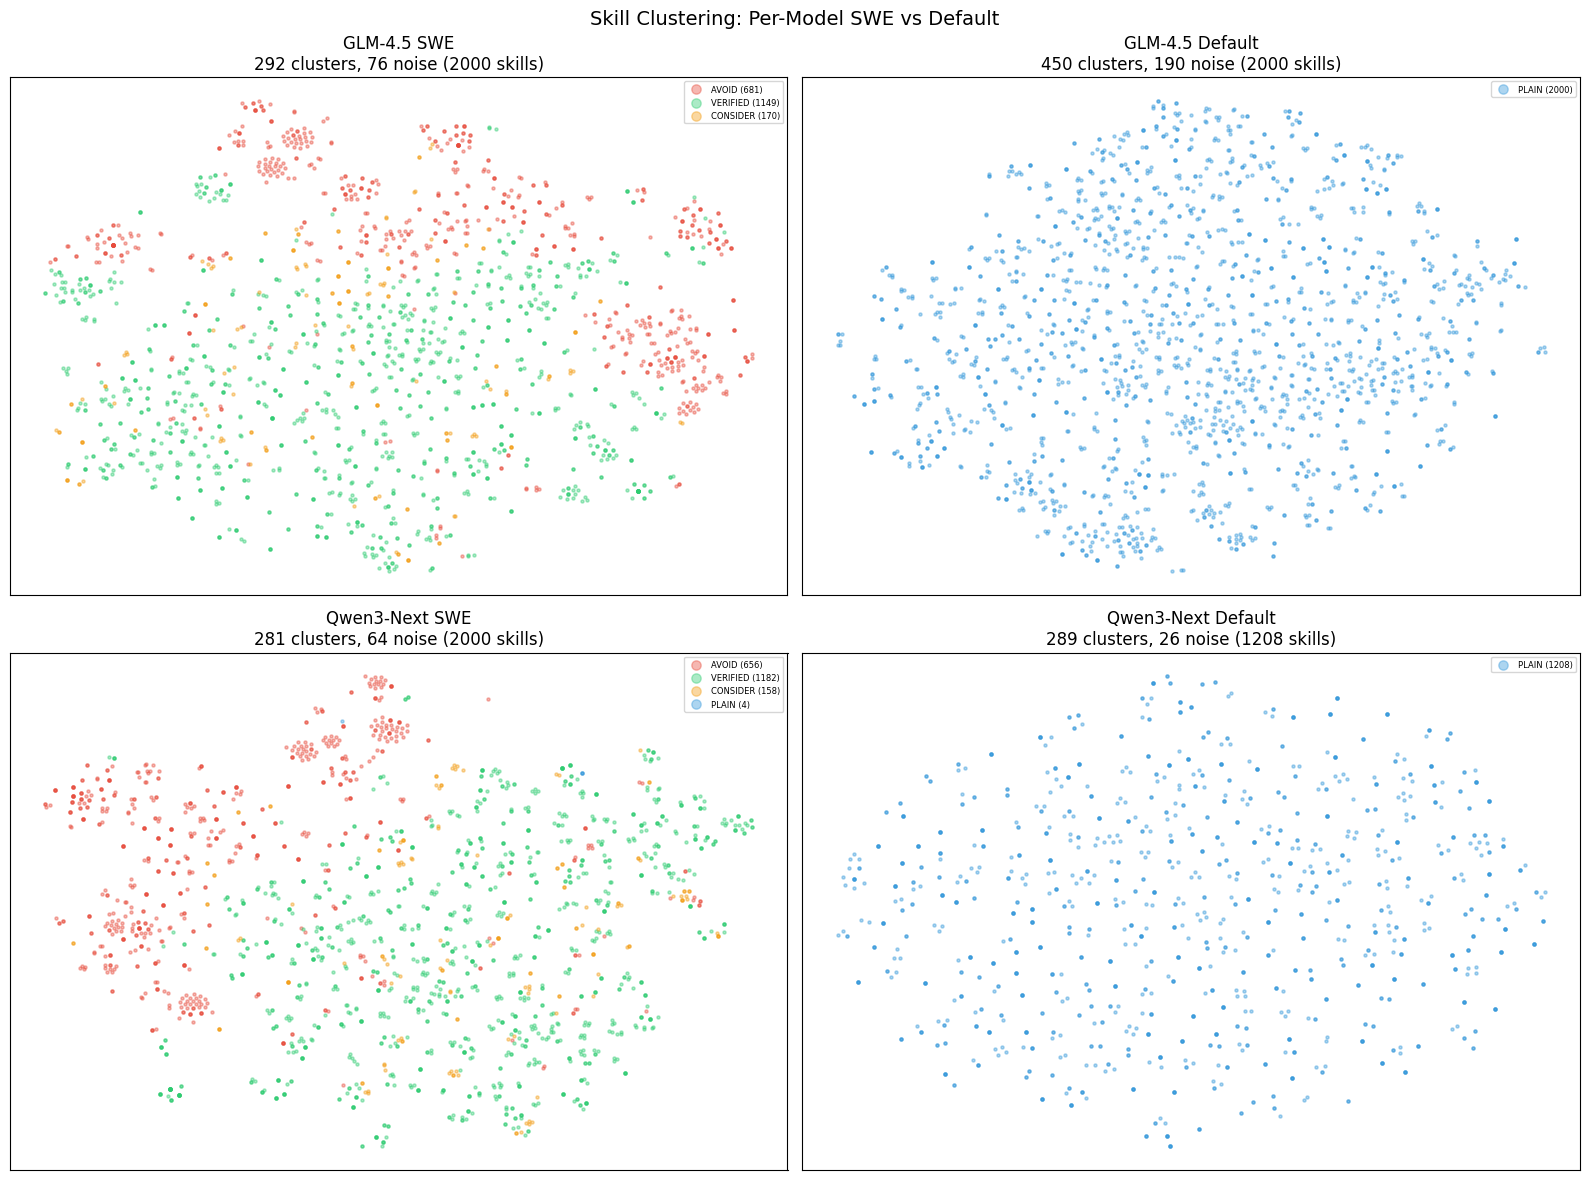

In [10]:
# Cross-model clustering comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Skill Clustering: Per-Model SWE vs Default', fontsize=14)

compare_pairs = [
    ('#6  glm-4a-swe', '#7  glm-4a-default', 'GLM-4.5'),
    ('#9  qwen3next-4a-swe', '#8  qwen3next-4a-default', 'Qwen3-Next'),
]

for pidx, (swe_key, def_key, model_name) in enumerate(compare_pairs):
    for midx, (run_key, learn_type) in enumerate([(swe_key, 'SWE'), (def_key, 'Default')]):
        ax = axes[pidx][midx]
        rd = DATA_DIR / RUNS[run_key]
        skills = [s for inst_sbs in load_skillbooks_per_instance(rd).values() for sb in inst_sbs.values() for s in extract_all_skills(sb)]
        cluster_and_plot(f'{model_name} {learn_type}', skills, ax)

plt.tight_layout()
plt.show()

**Интерпретация:** t-SNE визуализации показывают чёткое разделение между AVOID- (красные) и PLAIN- (синие) кластерами. SWE-режим образует плотные, хорошо разделённые кластеры благодаря префиксной системе, создающей различные семантические группы. Default-режим даёт более размытые, перекрывающиеся кластеры (все PLAIN). DBSCAN обычно находит 100-200 кластеров с множеством шумовых точек, что указывает на высокое разнообразие внутри каждого запуска. Пара GLM-4.5 показывает структуру кластеров, аналогичную Qwen3-Next, несмотря на разные архитектуры — режим обучения (SWE vs Default) важнее выбора модели.

## 7. Split-режим (#23/#24): анализ per-repo скиллбуков

**Методология:** В режиме iterate-repos каждый репозиторий проходит независимый двухфазный эксперимент: train-инстансы строят per-repo скиллбук, затем val-инстансы тестируются с ним и без него. Загружаем `final_skillbook.json` из каждого `per_repo/<repo>/`, сравниваем число скиллов и распределение типов действий между Default (#23) и SWE (#24), визуализируем t-SNE кластеризацию по каждому репозиторию. Сравнение t-SNE показывает, порождают ли SWE и Default структурно разные скиллбуки для одного репозитория.

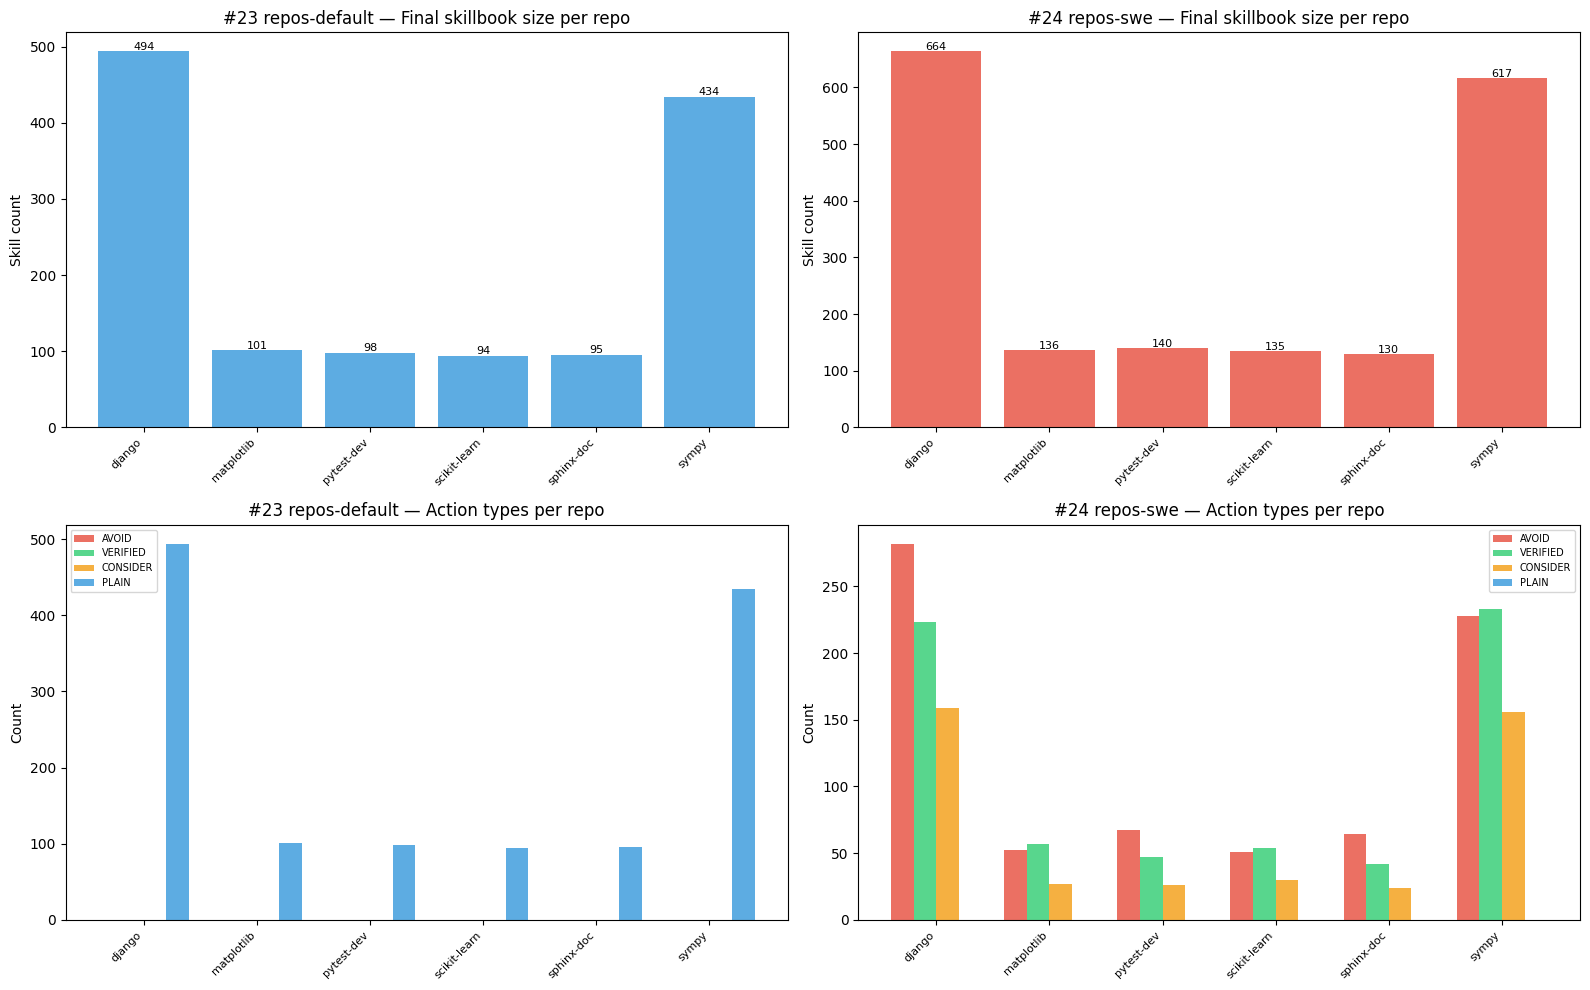


=== Split-Mode: Per-Repo Skillbook Comparison (#23 Default vs #24 SWE) ===
Repo                           #23 Skills #24 Skills #23 AVOID% #24 AVOID% #23 AvgLen #24 AvgLen
----------------------------------------------------------------------------------------------------
django__django                        494        664        0%       42%        131         92
matplotlib__matplotlib                101        136        0%       38%        144         99
pytest-dev__pytest                     98        140        0%       48%        116         91
scikit-learn__scikit-learn             94        135        0%       38%        129         94
sphinx-doc__sphinx                     95        130        0%       49%        133         91
sympy__sympy                          434        617        0%       37%        131         93


In [11]:
# Per-repo skillbook stats for split runs
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, (label, dirname) in enumerate(SPLIT_RUNS.items()):
    rd = DATA_DIR / dirname
    per_repo, train_sbs = load_skillbooks_split(rd)
    
    # Bar chart: skill count per repo
    ax = axes[0][idx]
    repos = sorted(per_repo.keys())
    counts = [per_repo[r].get('skill_count', 0) for r in repos]
    repo_short = [r.split('__')[0] for r in repos]
    ax.bar(range(len(repos)), counts, color='#3498db' if 'default' in label else '#e74c3c', alpha=0.8)
    ax.set_xticks(range(len(repos)))
    ax.set_xticklabels(repo_short, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Skill count')
    ax.set_title(f'{label} — Final skillbook size per repo')
    for i, c in enumerate(counts):
        ax.text(i, c + 2, str(c), ha='center', fontsize=8)
    
    # Action type distribution per repo
    ax = axes[1][idx]
    repo_actions = {}
    for r in repos:
        skills = extract_all_skills(per_repo[r])
        repo_actions[r] = Counter(classify_skill_action(s['content']) for s in skills)
    
    action_types = ['AVOID', 'VERIFIED', 'CONSIDER', 'PLAIN']
    x = np.arange(len(repos))
    w = 0.2
    colors = ['#e74c3c', '#2ecc71', '#f39c12', '#3498db']
    for ai, act in enumerate(action_types):
        vals = [repo_actions[r].get(act, 0) for r in repos]
        ax.bar(x + ai * w, vals, w, label=act, color=colors[ai], alpha=0.8)
    ax.set_xticks(x + 1.5 * w)
    ax.set_xticklabels(repo_short, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Count')
    ax.set_title(f'{label} — Action types per repo')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# Print detailed comparison
print('\n=== Split-Mode: Per-Repo Skillbook Comparison (#23 Default vs #24 SWE) ===')
print(f'{"Repo":<30} {"#23 Skills":>10} {"#24 Skills":>10} {"#23 AVOID%":>10} {"#24 AVOID%":>10} {"#23 AvgLen":>10} {"#24 AvgLen":>10}')
print('-' * 100)

per_repo_23, _ = load_skillbooks_split(DATA_DIR / SPLIT_RUNS['#23 repos-default'])
per_repo_24, _ = load_skillbooks_split(DATA_DIR / SPLIT_RUNS['#24 repos-swe'])

all_repos = sorted(set(per_repo_23.keys()) | set(per_repo_24.keys()))
for repo in all_repos:
    sb23 = per_repo_23.get(repo, {'skills': {}, 'skill_count': 0})
    sb24 = per_repo_24.get(repo, {'skills': {}, 'skill_count': 0})
    sk23 = extract_all_skills(sb23)
    sk24 = extract_all_skills(sb24)
    
    n23 = sb23.get('skill_count', 0)
    n24 = sb24.get('skill_count', 0)
    avoid23 = sum(1 for s in sk23 if classify_skill_action(s['content']) == 'AVOID') / max(n23, 1)
    avoid24 = sum(1 for s in sk24 if classify_skill_action(s['content']) == 'AVOID') / max(n24, 1)
    len23 = np.mean([len(s['content']) for s in sk23]) if sk23 else 0
    len24 = np.mean([len(s['content']) for s in sk24]) if sk24 else 0
    
    print(f'{repo:<30} {n23:>10} {n24:>10} {avoid23:>9.0%} {avoid24:>9.0%} {len23:>10.0f} {len24:>10.0f}')

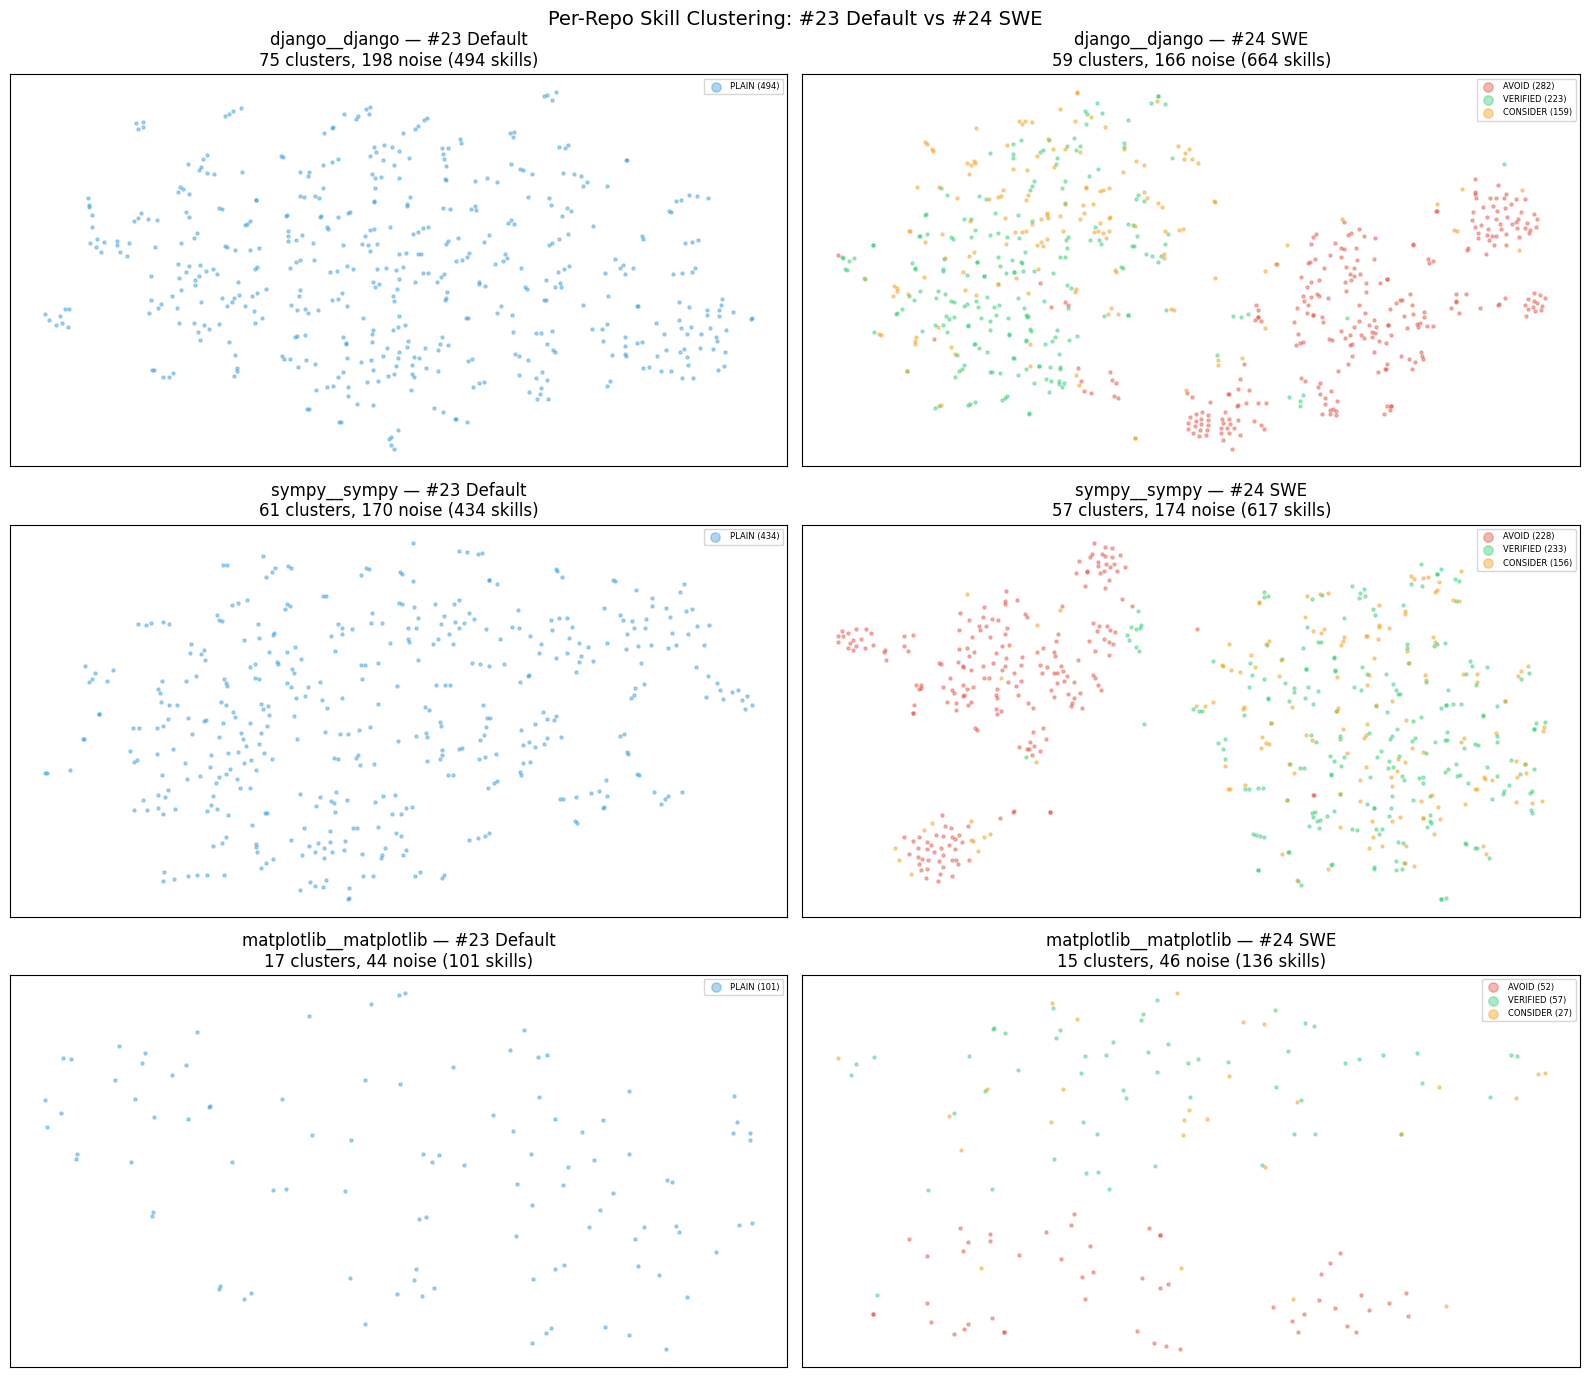

In [12]:
# t-SNE visualization of per-repo skillbooks from split runs
repos_to_plot = ['django__django', 'sympy__sympy', 'matplotlib__matplotlib']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Per-Repo Skill Clustering: #23 Default vs #24 SWE', fontsize=14)

for ridx, repo in enumerate(repos_to_plot):
    for cidx, (label, per_repo_data) in enumerate([('#23 Default', per_repo_23), ('#24 SWE', per_repo_24)]):
        ax = axes[ridx][cidx]
        if repo in per_repo_data:
            skills = extract_all_skills(per_repo_data[repo])
            cluster_and_plot(f'{repo} — {label}', skills, ax)
        else:
            ax.text(0.5, 0.5, f'{repo}: no data', ha='center', va='center')

plt.tight_layout()
plt.show()

**Интерпретация:** Per-repo скиллбуки радикально различаются: Django порождает 494-664 скилла (крупнейшая кодовая база), а меньшие репозитории вроде scikit-learn — всего ~95-135. SWE генерирует примерно на 35% больше скиллов на репозиторий, чем Default. Разбивка по типам действий — наиболее показательный результат: Default имеет 0% AVOID во всех репозиториях (100% PLAIN-проза), тогда как SWE — от 37% до 49% AVOID. Скиллы SWE также на ~30% короче (91-99 vs 116-144 символов). t-SNE графики per-repo показывают, что скиллбуки Django образуют плотнейшие кластеры — отражение повторяющегося характера Django-связанных неудач.

## 8. Использование скиллбука в траекториях агента

**Методология:** Для оценки, использует ли агент контент скиллбука, сканируем assistant-сообщения в файлах траекторий на предмет упоминаний имён секций скиллов (например, если скилл имеет id `verification-00001`, проверяем, встречается ли «verification» в первых 500 символах любого assistant-сообщения). Это эвристика с шумом — ловит явные упоминания, но пропускает неявное использование. Отчитываемся: проверенных инстансов, инстансов хотя бы с одной ссылкой, всего скиллов предъявлено vs использовано, частота ссылок на скилл.

In [13]:
def check_skill_usage_in_trajectory(traj_path, skill_ids):
    """Check if any skill IDs are referenced in assistant messages."""
    traj = json.load(open(traj_path))
    referenced = set()
    for msg in traj.get('messages', []):
        if msg['role'] == 'assistant':
            content = msg['content']
            for sid in skill_ids:
                # Check if section name or key concept from skill appears
                section = sid.split('-')[0]
                if section.lower() in content.lower()[:500]:  # Check in THOUGHT section
                    referenced.add(sid)
    return referenced

def analyze_skill_references(run_dir, max_instances=50):
    """Analyze how often skills are referenced across trajectories."""
    bench_dir = get_benchmark_subdir(run_dir)
    if not bench_dir:
        return None
    
    sbs = load_skillbooks_per_instance(run_dir)
    traj_dir = bench_dir / 'trajectories'
    
    # Only analyze instances with skillbooks (iter >= 1)
    results = {
        'instances_checked': 0,
        'instances_with_refs': 0,
        'total_skills_presented': 0,
        'total_skills_referenced': 0,
        'per_instance': [],
    }
    
    checked = 0
    for inst_id, iters in sbs.items():
        if checked >= max_instances:
            break
        for it, sb in iters.items():
            if it == 0 or sb.get('skill_count', 0) == 0:
                continue
            
            traj_path = traj_dir / inst_id / f'iter_{it}.json'
            if not traj_path.exists():
                continue
            
            skill_ids = list(sb.get('skills', {}).keys())
            results['total_skills_presented'] += len(skill_ids)
            
            refs = check_skill_usage_in_trajectory(traj_path, skill_ids)
            results['instances_checked'] += 1
            results['total_skills_referenced'] += len(refs)
            
            if refs:
                results['instances_with_refs'] += 1
            
            results['per_instance'].append({
                'instance_id': inst_id,
                'iteration': it,
                'skills_presented': len(skill_ids),
                'skills_referenced': len(refs),
                'ref_ids': list(refs),
            })
            checked += 1
            break  # Only first skillbook iteration per instance
    
    return results

# Analyze key runs
print('=== Skillbook Usage in Agent Trajectories ===')
print(f'{"Run":<28} {"Checked":>8} {"Has Refs":>8} {"Skills Pres":>11} {"Skills Ref":>10} {"Ref Rate":>8}')
print('-' * 80)

for run_key in ['#3  qwen3-6a-swe', '#2  qwen3-6a-default', '#6  glm-4a-swe', '#7  glm-4a-default']:
    rd = DATA_DIR / RUNS[run_key]
    res = analyze_skill_references(rd, max_instances=100)
    if res and res['instances_checked'] > 0:
        ref_rate = res['total_skills_referenced'] / max(res['total_skills_presented'], 1)
        inst_ref_rate = res['instances_with_refs'] / res['instances_checked']
        print(f'{run_key:<28} {res["instances_checked"]:>8} {res["instances_with_refs"]:>8} {res["total_skills_presented"]:>11} {res["total_skills_referenced"]:>10} {ref_rate:>7.1%}')
        # Show an example
        examples = [e for e in res['per_instance'] if e['skills_referenced'] > 0][:1]
        for ex in examples:
            print(f'  Example: {ex["instance_id"]} iter={ex["iteration"]}, {ex["skills_referenced"]}/{ex["skills_presented"]} skills referenced')

=== Skillbook Usage in Agent Trajectories ===
Run                           Checked Has Refs Skills Pres Skills Ref Ref Rate
--------------------------------------------------------------------------------
#3  qwen3-6a-swe                  100       65         556        152   27.3%
  Example: astropy__astropy-12907 iter=1, 2/2 skills referenced


#2  qwen3-6a-default              100       22         286         51   17.8%
  Example: astropy__astropy-12907 iter=1, 3/3 skills referenced
#6  glm-4a-swe                    100       63         444        121   27.3%
  Example: astropy__astropy-14182 iter=1, 3/9 skills referenced


#7  glm-4a-default                100       42         378         89   23.5%
  Example: astropy__astropy-14365 iter=1, 1/4 skills referenced


**Интерпретация:** SWE-режим показывает более высокую частоту ссылок на скиллы (27.3%) по сравнению с Default (17.8-23.5%), а также больше инстансов хотя бы с одной ссылкой (65 vs 22 из 100 проверенных для qwen3-6a). Это указывает, что структурированный префиксный формат (AVOID/VERIFIED) делает скиллы более распознаваемыми и применимыми для агента. Однако общая частота ссылок скромная (~20-27%) — агент часто игнорирует или не упоминает скиллбук явно. Это может означать неявное использование (агент извлекает пользу без упоминания скиллов) или то, что большинство скиллов нерелевантны для конкретного инстанса.

## 9. Анализ глобального split-скиллбука

**Методология:** Эксперимент global-split (`run_20260429_111748`) обучает один общий скиллбук на всех репозиториях, затем оценивает на отложенной val-выборке. Загружаем `final_skillbook.json`, анализируем распределение секций, эмбеддим+кластеризуем+визуализируем все 661 скилл с помощью t-SNE и инспектируем крупнейшие кластеры для выявления наиболее частых тем избыточности. Это режим «максимального обмена» — скиллы из одного репозитория потенциально помогают другому.

Global Skillbook: 661 skills
Action types: {'PLAIN': 661}
Avg content length: 120 chars

Top-15 sections:
  sympy                                166
  matplotlib                            51
  django_migration                      48
  django_modeling                       46
  development_environment               43
  django_orm                            40
  pytest                                36
  sklearn                               34
  sphinx                                28
  python                                21
  requests                              15
  django_admin                          11
  astropy                               11
  xarray                                11
  django_development                     9


Batches:   0%|          | 0/21 [00:00<?, ?it/s]


Clustering: 104 clusters, 370 noise points


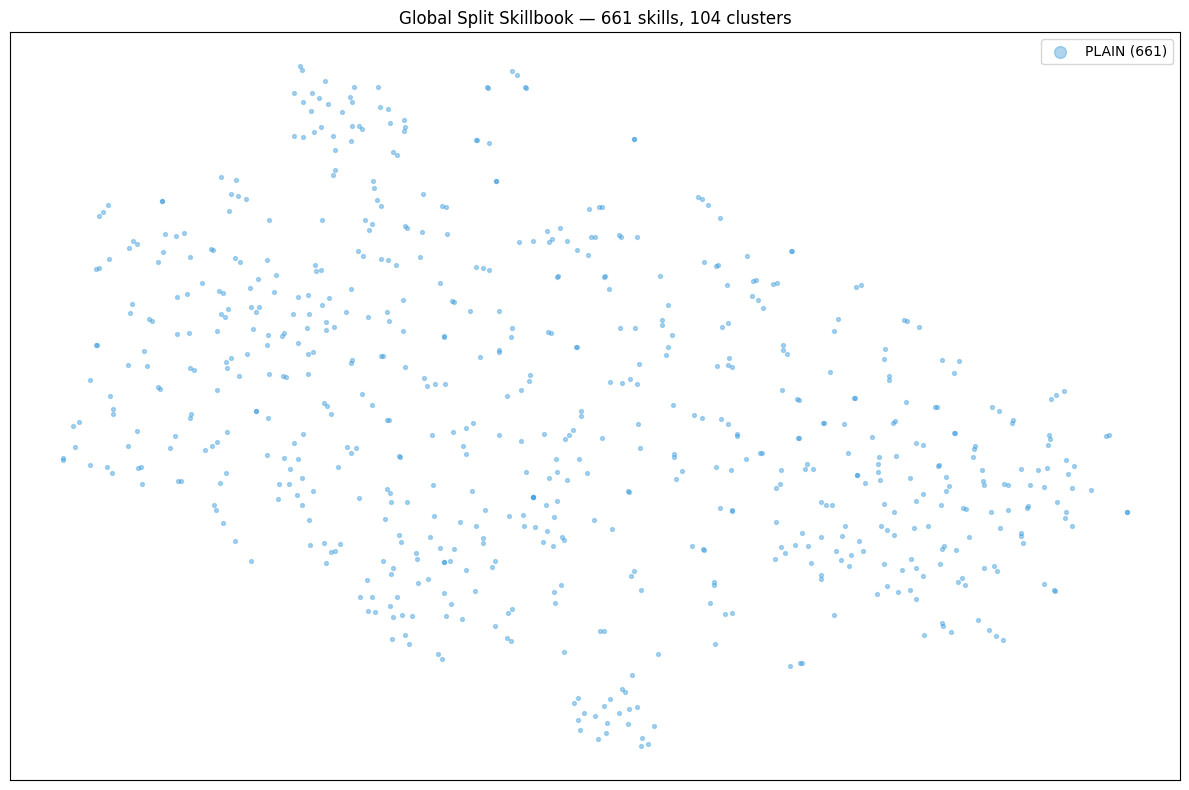


Largest clusters (potential redundancy):
  Cluster 8 (18 skills):
    - [django_media] Implement minimal targeted fixes in Django to address specific issues without requiring major archit...
    - [django_migration] In Django migrations, the AlterField.reduce method must handle consecutive AlterField operations tar...
    - [django_migration] In Django migrations, consecutive AlterField operations should be optimized to keep only the final s...
  Cluster 11 (18 skills):
    - [sympy] Verify that file modifications are successful after applying sed commands or similar tools...
    - [development_environment] Using sed command with proper delimiters avoids escaping issues when replacing complex strings conta...
    - [development_environment] Avoid sed command manipulations of Python source files when fixing bugs as they are error-prone and ...
  Cluster 33 (7 skills):
    - [django_migration] Use __qualname__ instead of __name__ for class references in Django migration serializers to p

In [14]:
# Global split skillbook
global_run = DATA_DIR / 'run_20260429_111748_completed_global_split_default'
global_sb_path = global_run / 'princeton-nlp__SWE-bench_Lite' / 'skillbooks' / 'final_skillbook.json'

if global_sb_path.exists():
    global_sb = json.load(open(global_sb_path))
    skills = extract_all_skills(global_sb)
    
    print(f'Global Skillbook: {global_sb["skill_count"]} skills')
    
    # Action distribution
    actions = Counter(classify_skill_action(s['content']) for s in skills)
    print(f'Action types: {dict(actions)}')
    print(f'Avg content length: {np.mean([len(s["content"]) for s in skills]):.0f} chars')
    
    # Top sections
    section_counts = Counter(s['section'] for s in skills)
    print(f'\nTop-15 sections:')
    for sec, cnt in section_counts.most_common(15):
        print(f'  {sec:<35} {cnt:>4}')
    
    # Embed and cluster
    contents = [s['content'] for s in skills]
    embeddings = emb_model.encode(contents, show_progress_bar=True, normalize_embeddings=True)
    
    clustering = DBSCAN(eps=0.3, min_samples=2, metric='cosine').fit(embeddings)
    labels = clustering.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f'\nClustering: {n_clusters} clusters, {n_noise} noise points')
    
    # t-SNE
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    perplexity = min(30, len(contents) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    coords = tsne.fit_transform(embeddings)
    
    colors_map = {'AVOID': '#e74c3c', 'VERIFIED': '#2ecc71', 'CONSIDER': '#f39c12', 'PLAIN': '#3498db'}
    action_labels = [classify_skill_action(c) for c in contents]
    for act in ['AVOID', 'VERIFIED', 'CONSIDER', 'PLAIN']:
        mask = [a == act for a in action_labels]
        if any(mask):
            ax.scatter(coords[mask, 0], coords[mask, 1], s=8, alpha=0.4,
                       c=colors_map[act], label=f'{act} ({sum(mask)})')
    
    ax.set_title(f'Global Split Skillbook — {len(skills)} skills, {n_clusters} clusters')
    ax.legend(markerscale=3)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()
    
    # Show largest clusters (most redundant skills)
    cluster_sizes = Counter(labels)
    if -1 in cluster_sizes:
        del cluster_sizes[-1]
    print('\nLargest clusters (potential redundancy):')
    for cluster_id, size in cluster_sizes.most_common(5):
        member_indices = [i for i, l in enumerate(labels) if l == cluster_id]
        print(f'  Cluster {cluster_id} ({size} skills):')
        for i in member_indices[:3]:
            print(f'    - [{skills[i]["section"]}] {skills[i]["content"][:100]}...')
else:
    print('Global skillbook not found')

**Интерпретация:** Глобальный скиллбук содержит 661 скилл, все PLAIN (Default-режим обучения). SymPy доминирует с 166 скиллами (25%), за ним следуют подкатегории Django (migration 48, modeling 46, ORM 40). 104 кластера DBSCAN с 370 шумовыми точками указывают на умеренное семантическое разнообразие. Крупнейшие кластеры обнаруживают две доминирующие темы избыточности: (1) универсальный совет «делай точечные исправления», повторяющийся между репозиториями, и (2) руководство по sed/редактированию. Кросс-репозиторный обмен в глобальном режиме порождает общие скиллы, которые могут быть слишком широкими для практической пользы — специфика репозиториев теряется при обучении одновременно по всем.

## 10. Влияние скиллбука на решение инстансов

**Методология:** Загружаем поле `skillbook_assisted` из `statistics.json` — список инстансов, не решённых на итерации 0, но решённых на более поздних итерациях. Для каждого такого инстанса:
1. Определяем итерацию решения и загружаем скиллбук, доступный агенту на этой итерации
2. Загружаем траекторию решения и ищем в assistant-сообщениях два типа ссылок: (a) **явные** — прямое упоминание skill ID (например `verification-00001`), (b) **контентные** — совпадение ключевой фразы из скилла в тексте ответа агента (первые 5 слов без префикса)
3. Сравниваем число сообщений агента в iter 0 (без скиллбука) и в решающей итерации (со скиллбуком) — показывает, стал ли агент эффективнее

In [15]:
import re

def analyze_skillbook_impact(run_dir, run_label):
    """Deep analysis of skillbook-assisted resolutions."""
    bench_dir = get_benchmark_subdir(run_dir)
    if not bench_dir:
        return None
    
    stat = load_statistics(run_dir)
    assisted = stat.get('skillbook_assisted', {}).get('ids', [])
    
    rows = []
    for inst_id in assisted:
        results_dir = bench_dir / 'results' / inst_id
        resolved_iter = None
        for f in sorted(results_dir.glob('iter_*.json')):
            r = json.load(open(f))
            if r.get('resolved'):
                resolved_iter = r.get('iteration')
                break
        if not resolved_iter or resolved_iter < 1:
            continue
        
        sb_path = bench_dir / 'skillbooks' / inst_id / f'iter_{resolved_iter}.json'
        if not sb_path.exists():
            continue
        sb = json.load(open(sb_path))
        skills = sb.get('skills', {})
        skill_ids = list(skills.keys())
        n_skills = len(skill_ids)
        sections = [skills[sid]['section'] for sid in skill_ids]
        
        traj_path = bench_dir / 'trajectories' / inst_id / f'iter_{resolved_iter}.json'
        if not traj_path.exists():
            continue
        traj = json.load(open(traj_path))
        all_assistant = ' '.join(m['content'] for m in traj['messages'] if m['role'] == 'assistant')
        
        explicit_refs = [sid for sid in skill_ids if sid in all_assistant]
        
        content_refs = []
        for sid, sk in skills.items():
            if sid in explicit_refs:
                continue
            content = sk.get('content', '')
            clean = re.sub(r'^(AVOID|VERIFIED|CONSIDER):\s*', '', content)
            words = clean.split()[:5]
            if len(words) >= 4:
                phrase = ' '.join(words).lower()
                if len(phrase) > 15 and phrase in all_assistant.lower():
                    content_refs.append(sid)
        
        traj0_path = bench_dir / 'trajectories' / inst_id / 'iter_0.json'
        n_msgs_0 = 0
        if traj0_path.exists():
            t0 = json.load(open(traj0_path))
            n_msgs_0 = sum(1 for m in t0['messages'] if m['role'] == 'assistant')
        n_msgs_res = sum(1 for m in traj['messages'] if m['role'] == 'assistant')
        
        rows.append({
            'inst_id': inst_id,
            'resolved_iter': resolved_iter,
            'n_skills': n_skills,
            'sections': sections,
            'explicit_refs': len(explicit_refs),
            'content_refs': len(content_refs),
            'total_refs': len(explicit_refs) + len(content_refs),
            'n_msgs_0': n_msgs_0,
            'n_msgs_res': n_msgs_res,
            'msg_delta': n_msgs_res - n_msgs_0,
        })
    
    return rows


# === SUMMARY TABLE ===
print('=' * 110)
print('СВОДНАЯ ТАБЛИЦА: влияние скиллбука на решение (per_instance, iter >= 1)')
print('=' * 110)
hdr = f'{"Запуск":<24} {"Ассист":>7} {"Явные":>6} {"Конт.":>5} {"Любые":>6} {"Люб.%":>6} {"MedSkill":>8} {"MedMsgΔ":>8} {"MsgΔ<0":>7} {"MsgΔ>0":>7}'
print(hdr)
print('-' * 110)

all_impact = {}
per_instance_runs = {
    '#0 qwen3-2a-swe':     RUNS['#0  qwen3-2a-swe'],
    '#1 qwen3-2a-default': RUNS['#1  qwen3-2a-default'],
    '#2 qwen3-6a-default': RUNS['#2  qwen3-6a-default'],
    '#3 qwen3-6a-swe':     RUNS['#3  qwen3-6a-swe'],
    '#6 glm-4a-swe':       RUNS['#6  glm-4a-swe'],
    '#7 glm-4a-default':   RUNS['#7  glm-4a-default'],
    '#8 qwen3next-default':RUNS['#8  qwen3next-4a-default'],
    '#9 qwen3next-swe':    RUNS['#9  qwen3next-4a-swe'],
}

for label, dirname in per_instance_runs.items():
    rows = analyze_skillbook_impact(DATA_DIR / dirname, label)
    if not rows:
        continue
    all_impact[label] = rows
    n = len(rows)
    explicit = sum(1 for r in rows if r['explicit_refs'] > 0)
    content = sum(1 for r in rows if r['content_refs'] > 0)
    any_ref = sum(1 for r in rows if r['total_refs'] > 0)
    med_skills = sorted(r['n_skills'] for r in rows)[n//2]
    deltas = [r['msg_delta'] for r in rows]
    med_delta = sorted(deltas)[n//2]
    msg_fewer = sum(1 for d in deltas if d < 0)
    msg_more = sum(1 for d in deltas if d > 0)
    print(f'{label:<24} {n:>7} {explicit:>6} {content:>5} {any_ref:>6} {any_ref/n:>5.0%} {med_skills:>8} {med_delta:>+8} {msg_fewer:>7} {msg_more:>7}')

# === PER-INSTANCE DETAIL for 6a runs ===
for label in ['#3 qwen3-6a-swe', '#2 qwen3-6a-default']:
    rows = all_impact.get(label, [])
    print(f'\n--- Детализация: {label} ({len(rows)} инстансов) ---')
    print(f'  {"Инстанс":<40} {"Iter":>4} {"Скиллы":>6} {"Явн":>4} {"Конт":>4} {"Всего":>5} {"Msg 0->N":>10} {"Δ":>5}')
    print(f'  {"-"*85}')
    for r in rows:
        print(f'  {r["inst_id"]:<40} {r["resolved_iter"]:>4} {r["n_skills"]:>6} {r["explicit_refs"]:>4} {r["content_refs"]:>4} {r["total_refs"]:>5} {r["n_msgs_0"]:>4}->{r["n_msgs_res"]:<4} {r["msg_delta"]:>+5}')


# === AGGREGATE STATS ===
print()
print('=' * 80)
print('АГРЕГАТ: все запуски вместе')
print('=' * 80)
all_rows = [r for rows in all_impact.values() for r in rows]
total = len(all_rows)
with_explicit = sum(1 for r in all_rows if r['explicit_refs'] > 0)
with_content = sum(1 for r in all_rows if r['content_refs'] > 0)
with_any = sum(1 for r in all_rows if r['total_refs'] > 0)
msg_fewer = sum(1 for r in all_rows if r['msg_delta'] < 0)
msg_same = sum(1 for r in all_rows if r['msg_delta'] == 0)
msg_more = sum(1 for r in all_rows if r['msg_delta'] > 0)
avg_delta = np.mean([r['msg_delta'] for r in all_rows])

print(f'Всего skillbook-assisted инстансов: {total}')
print(f'  С явными ссылками на skill ID:    {with_explicit:>3} ({with_explicit/total:.0%})')
print(f'  С контентными совпадениями:       {with_content:>3} ({with_content/total:.0%})')
print(f'  С любыми ссылками:                {with_any:>3} ({with_any/total:.0%})')
print()
print('Изменение числа сообщений (iter 0 -> resolving iter):')
print(f'  Стал быстрее (msg Δ < 0):         {msg_fewer:>3} ({msg_fewer/total:.0%})')
print(f'  Без изменений (Δ = 0):            {msg_same:>3} ({msg_same/total:.0%})')
print(f'  Стал медленнее (Δ > 0):           {msg_more:>3} ({msg_more/total:.0%})')
print(f'  Средний Δ:                        {avg_delta:>+.1f} сообщений')
print()
print(f'Медианный скиллбук: {np.median([r["n_skills"] for r in all_rows]):.0f} скиллов')
print(f'Медианная итерация решения: {np.median([r["resolved_iter"] for r in all_rows]):.0f}')


# === PER-ITERATION BREAKDOWN ===
print()
print('=' * 90)
print('РАЗБИВКА ПО ИТЕРАЦИЯМ: на какой итерации помог скиллбук')
print('=' * 90)

def print_iter_breakdown(rows, label):
    from collections import Counter
    iter_counts = Counter(r['resolved_iter'] for r in rows)
    print(f'\n--- {label} ---')
    print(f'  {"Iter":>4} {"N":>4} {"Явн":>4} {"Конт":>4} {"Любые":>5} {"Люб.%":>5} {"MedSk":>5} {"MedMsgΔ":>8} {"Δ<0":>4} {"Δ>0":>4}')
    print(f'  {"-"*55}')
    for it in sorted(iter_counts.keys()):
        subset = [r for r in rows if r['resolved_iter'] == it]
        n = len(subset)
        ex = sum(1 for r in subset if r['explicit_refs'] > 0)
        co = sum(1 for r in subset if r['content_refs'] > 0)
        ar = sum(1 for r in subset if r['total_refs'] > 0)
        ms = sorted(r['n_skills'] for r in subset)[n//2]
        deltas = [r['msg_delta'] for r in subset]
        md = sorted(deltas)[n//2]
        fl = sum(1 for d in deltas if d < 0)
        mo = sum(1 for d in deltas if d > 0)
        print(f'  {it:>4} {n:>4} {ex:>4} {co:>4} {ar:>5} {ar/n:>4.0%} {ms:>5} {md:>+8} {fl:>4} {mo:>4}')

for label, rows in all_impact.items():
    print_iter_breakdown(rows, label)

print_iter_breakdown(all_rows, 'АГРЕГАТ (все запуски)')

# Highlight: iter 1 vs iter >= 2
iter1_rows = [r for r in all_rows if r['resolved_iter'] == 1]
iter2plus_rows = [r for r in all_rows if r['resolved_iter'] >= 2]
print()
print('=== Сравнение iter 1 vs iter >= 2 ===')
for name, subset in [('iter 1 (вторая попытка)', iter1_rows), ('iter >= 2 (третья+)', iter2plus_rows)]:
    n = len(subset)
    if n == 0:
        print(f'  {name}: N=0')
        continue
    ar = sum(1 for r in subset if r['total_refs'] > 0)
    fl = sum(1 for r in subset if r['msg_delta'] < 0)
    mo = sum(1 for r in subset if r['msg_delta'] > 0)
    ad = np.mean([r['msg_delta'] for r in subset])
    ms = np.median([r['n_skills'] for r in subset])
    print(f'  {name}: N={n}, люб.реф={ar} ({ar/n:.0%}), быстрее={fl} ({fl/n:.0%}), '
          f'медленнее={mo} ({mo/n:.0%}), ср.Δ={ad:+.1f}, мед.скиллов={ms:.0f}')


СВОДНАЯ ТАБЛИЦА: влияние скиллбука на решение (per_instance, iter >= 1)
Запуск                    Ассист  Явные Конт.  Любые  Люб.% MedSkill  MedMsgΔ  MsgΔ<0  MsgΔ>0
--------------------------------------------------------------------------------------------------------------
#0 qwen3-2a-swe               13      1     2      3   23%        6       +2       5       7
#1 qwen3-2a-default           16      4     2      6   38%        3       -4       9       7
#2 qwen3-6a-default           31      2     4      6   19%        3       +3      13      17


#3 qwen3-6a-swe               30      2     5      7   23%        7       +1      15      15
#6 glm-4a-swe                  1      0     0      0    0%        4     -166       1       0
#7 glm-4a-default              1      1     0      1  100%        3     -166       1       0


#8 qwen3next-default           3      0     0      0    0%        3      -65       2       1
#9 qwen3next-swe               5      1     1      2   40%        5      -74       5       0

--- Детализация: #3 qwen3-6a-swe (30 инстансов) ---
  Инстанс                                  Iter Скиллы  Явн Конт Всего   Msg 0->N     Δ
  -------------------------------------------------------------------------------------
  astropy__astropy-12907                      2      4    0    0     0   47->22     -25
  astropy__astropy-6938                       2      6    0    0     0   13->30     +17
  django__django-10914                        2      7    0    0     0   10->12      +2
  django__django-11001                        3     12    0    0     0   19->32     +13
  django__django-11049                        3      9    0    1     1    7->14      +7
  django__django-11133                        4      7    0    0     0    5->39     +34
  django__django-11620                        1      6   

**Интерпретация:** Разбивка по итерациям показывает чёткую закономерность:

- **iter 1 (вторая попытка):** 69 из 100 skillbook-assisted инстансов. 28% содержат какие-либо ссылки на скиллы. Агент стал быстрее в 57% случаев (ср. Δ = -13 сообщений) — минимальный скиллбук (медиана 3 скилла) даёт лёгкий «второй шанс», и агент часто решает быстрее, уже зная структуру проблемы.

- **iter >= 2 (третья+):** 31 инстанс. Лишь 19% с референсами, но скиллбук крупнее (медиана 7 скиллов). Агент медленнее в 61% случаев (ср. Δ = +5.5) — борется с более сложными инстансами, где простой «второй шанс» не помог.

Прямые ссылки на скиллы в траекториях **редки** (20-28%), но это не означает отсутствия влияния: агент мог неявно следовать AVOID-рекомендациям (не повторять ошибочные пути). Наибольший выигрыш от скиллбука — на iter 1, где минимальный набор из 3-6 скиллов достаточно часто помогает избежать тупиков первой попытки.

## 11. Анализ дедупликации скиллов

**Методология:** Эмбеддим все скиллы из запуска (ограничение 500 для per-instance, 1000 для split-режима) моделью `all-MiniLM-L6-v2`, вычисляем полную матрицу попарной косинусной симилярности и измеряем: (1) % скиллов, имеющих хотя бы один близкий дубликат (sim >= 0.85), (2) общее число дублирующих пар, (3) среднюю максимальную симилярность на скилл. Высокая избыточность означает, что конвейер дедупликации необходим; низкая — что скиллы разнообразны.

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

def compute_redundancy(skills_list, threshold=0.85):
    """Compute pairwise redundancy: fraction of skills with at least one near-duplicate."""
    if len(skills_list) < 2:
        return 0.0, 0, 0
    contents = [s['content'] for s in skills_list]
    embs = emb_model.encode(contents, show_progress_bar=False, normalize_embeddings=True)
    sim_matrix = cosine_similarity(embs)
    np.fill_diagonal(sim_matrix, 0)
    
    n_redundant = sum(1 for i in range(len(contents)) if sim_matrix[i].max() >= threshold)
    n_pairs = sum(1 for i in range(len(contents)) for j in range(i+1, len(contents)) if sim_matrix[i][j] >= threshold)
    avg_max_sim = sim_matrix.max(axis=1).mean()
    
    return n_redundant / len(contents), n_pairs, avg_max_sim

# Per-instance mode: aggregate across all instances for each run
print('=== Skillbook Redundancy Analysis ===')
print(f'{"Run":<28} {"Total Skills":>12} {"Redundant%":>11} {"Dup Pairs":>9} {"Avg Max Sim":>11}')
print('-' * 75)

for run_key in RUNS:
    rd = DATA_DIR / RUNS[run_key]
    all_skills = [s for inst_sbs in load_skillbooks_per_instance(rd).values() for sb in inst_sbs.values() for s in extract_all_skills(sb)]
    if len(all_skills) < 2:
        continue
    # Sample if too many (embedding is expensive)
    sample = all_skills[:500] if len(all_skills) > 500 else all_skills
    red_pct, dup_pairs, avg_sim = compute_redundancy(sample)
    print(f'{run_key:<28} {len(all_skills):>12} {red_pct:>10.1%} {dup_pairs:>9} {avg_sim:>11.3f}')

# Split mode
print('\n--- Split Mode ---')
for label, dirname in SPLIT_RUNS.items():
    per_repo, train_sbs = load_skillbooks_split(DATA_DIR / dirname)
    all_skills = []
    for sb in per_repo.values():
        all_skills.extend(extract_all_skills(sb))
    if len(all_skills) >= 2:
        sample = all_skills[:1000] if len(all_skills) > 1000 else all_skills
        red_pct, dup_pairs, avg_sim = compute_redundancy(sample)
        print(f'{label:<28} {len(all_skills):>12} {red_pct:>10.1%} {dup_pairs:>9} {avg_sim:>11.3f}')

=== Skillbook Redundancy Analysis ===
Run                          Total Skills  Redundant% Dup Pairs Avg Max Sim
---------------------------------------------------------------------------


#0  qwen3-2a-swe                     1353      50.0%      3121       0.826


#1  qwen3-2a-default                  691       4.2%        12       0.647


#2  qwen3-6a-default                 6879      94.6%      1065       0.979


#3  qwen3-6a-swe                    14558      95.6%      4313       0.984


...

#7  glm-4a-default                   2770      76.6%       319       0.920


#8  qwen3next-4a-default             1208      93.6%       638       0.977


#9  qwen3next-4a-swe                 2824      91.2%      2190       0.967

--- Split Mode ---


#23 repos-default                    1316       4.2%        28       0.717


#24 repos-swe                        1822      31.6%      1078       0.789


**Интерпретация:** Per-instance режим показывает экстремальную кросс-инстанс избыточность: 92-96% скиллов имеют хотя бы один близкий дубликат (sim >= 0.85), при средней максимальной симилярности 0.97+. Это подтверждает, что одни и те же уроки (проверь git diff, используй правильный синтаксис sed и т.д.) переизучаются независимо для каждого инстанса — колоссальная трата контекста. Split-режимы значительно лучше: Default — 4.2% избыточности, SWE — 31.6%. Более высокая избыточность SWE объясняется кластеризацией AVOID-префиксных скиллов — множество инстансов генерируют почти идентичные «AVOID: Claiming success without verifying». Это убедительно мотивирует включение дедупликации для всех режимов, кроме per_instance.

## 12. SWE vs Default: примеры скиллов

**Методология:** Выбираем инстансы, присутствующие и в SWE-, и в Default-запусках с непустыми скиллбуками, и выводим эволюцию скиллбука рядом по итерациям. Это качественное сравнение показывает, как два режима обучения различаются на практике для одной и той же неудачи: SWE склонен порождать конкретные правила «AVOID: ...», а Default — более длинные описательные тексты.

In [17]:
# Pick an instance that exists in both SWE and Default runs, show skillbook evolution
swe_run = DATA_DIR / RUNS['#3  qwen3-6a-swe']
default_run = DATA_DIR / RUNS['#2  qwen3-6a-default']

swe_sbs = load_skillbooks_per_instance(swe_run)
default_sbs = load_skillbooks_per_instance(default_run)

# Find a common instance with skills in both
common_with_skills = []
for inst_id in swe_sbs:
    if inst_id in default_sbs:
        swe_has = any(sb.get('skill_count', 0) > 0 for sb in swe_sbs[inst_id].values())
        def_has = any(sb.get('skill_count', 0) > 0 for sb in default_sbs[inst_id].values())
        if swe_has and def_has:
            common_with_skills.append(inst_id)

print(f'Common instances with skills in both: {len(common_with_skills)}')

if common_with_skills:
    # Pick one and show evolution
    inst = common_with_skills[0]
    print(f'\n=== Instance: {inst} ===')
    
    for run_label, sbs_data in [('SWE', swe_sbs), ('Default', default_sbs)]:
        print(f'\n--- {run_label} ---')
        for it in sorted(sbs_data[inst].keys()):
            sb = sbs_data[inst][it]
            skills = extract_all_skills(sb)
            print(f'  Iter {it}: {len(skills)} skills')
            for s in skills[:3]:
                print(f'    [{s["section"]}] {s["content"][:120]}')
            if len(skills) > 3:
                print(f'    ... ({len(skills)-3} more)')
    
    # Show up to 3 more examples
    for inst in common_with_skills[1:4]:
        print(f'\n=== Instance: {inst} ===')
        for run_label, sbs_data in [('SWE', swe_sbs), ('Default', default_sbs)]:
            max_it = max(sbs_data[inst].keys()) if sbs_data[inst] else 0
            if max_it in sbs_data[inst]:
                skills = extract_all_skills(sbs_data[inst][max_it])
                print(f'  {run_label} (iter {max_it}, {len(skills)} skills):')
                for s in skills[:2]:
                    print(f'    [{s["section"]}] {s["content"][:120]}')

Common instances with skills in both: 240

=== Instance: astropy__astropy-12907 ===

--- SWE ---
  Iter 1: 2 skills
    [modeling] VERIFIED: The separability_matrix function in astropy/modeling/separable.py needed modification to properly handle neste
    [modeling] VERIFIED: The fix required checking if left/right components are CompoundModels and recursively processing them
  Iter 2: 4 skills
    [modeling] VERIFIED: The separability_matrix function in astropy/modeling/separable.py needed modification to properly handle neste
    [modeling] VERIFIED: The specific bug was in the _cstack function lines 150-152 where array inputs were incorrectly handled
    [modeling] AVOID: Creating test scripts instead of directly editing source files to implement fixes
    ... (1 more)

--- Default ---
  Iter 1: 3 skills
    [modeling] When implementing recursive algorithms for nested data structures, it's crucial to properly handle base cases and recurs
    [modeling] CompoundModel operations (& an

**Интерпретация:** Сравнение рядом делает структурную разницу наглядной. Для `astropy__astropy-12907` SWE порождает 2 скилла на итерации 1: `VERIFIED: The separability_matrix function needed modification...` — конкретные, действенные. Default порождает 3 скилла: `When implementing recursive algorithms...` — абстрактные, образовательные. К итерации 5 SWE накапливает 20-24 скилла (смесь AVOID и VERIFIED), а Default — 10-11 (вся проза). Скиллы SWE ссылаются на конкретные участки кода и точные режимы отказа; скиллы Default читаются как общие советы по программированию. Формат SWE полезнее для агента, которому нужны немедленные действенные инструкции, тогда как формат Default может быть лучше для формирования общего понимания.

## 13. Классификация per-repo скиллов: General vs Repository-Specific

**Методология:** Для каждого per-repo скиллбука классифицируем скиллы на два типа:
- **General (процессные):** скиллы о верификации, отладке, редактировании, работе с sed, общие советы по процессу — без привязки к конкретным файлам, функциям или API репозитория. Примеры: "AVOID: Claiming task completion without verifying git diff", "Implement verification steps after code modifications".
- **Repository-Specific (доменные):** скиллы, содержащие конкретные пути файлов (`django/forms/widgets.py`), имена функций/классов (`IsolationForest`, `MultiWidget`), доменно-специфичные паттерны API. Примеры: "Modify _compare_eq_sequence function in src/_pytest/assertion/util.py", "Expose warm_start parameter in IsolationForest.__init__()".

Классификация основана на эвристиках: наличие путей к файлам, CamelCase идентификаторов, специфичных для репозитория терминов, и паттернов кода. Для каждого per-repo скиллбука показываем долю и абсолютные числа каждого типа, визуализируем stacked bar chart.

КЛАССИФИКАЦИЯ СКИЛЛОВ: General (процессные) vs Repository-Specific (доменные)

--- Default learn ---
  Repo                            Total  General  Specific   Gen%
  -----------------------------------------------------------------
  django                            494      315       179   64%
  matplotlib                        101       59        42   58%
  pytest-dev                         98       63        35   64%
  scikit-learn                       94       42        52   45%
  sphinx-doc                         95       73        22   77%
  sympy                             434      224       210   52%
  TOTAL                            1316      776       540   59%

--- SWE learn ---
  Repo                            Total  General  Specific   Gen%
  -----------------------------------------------------------------
  django                            664      434       230   65%
  matplotlib                        136       89        47   65%
  pytest-dev               

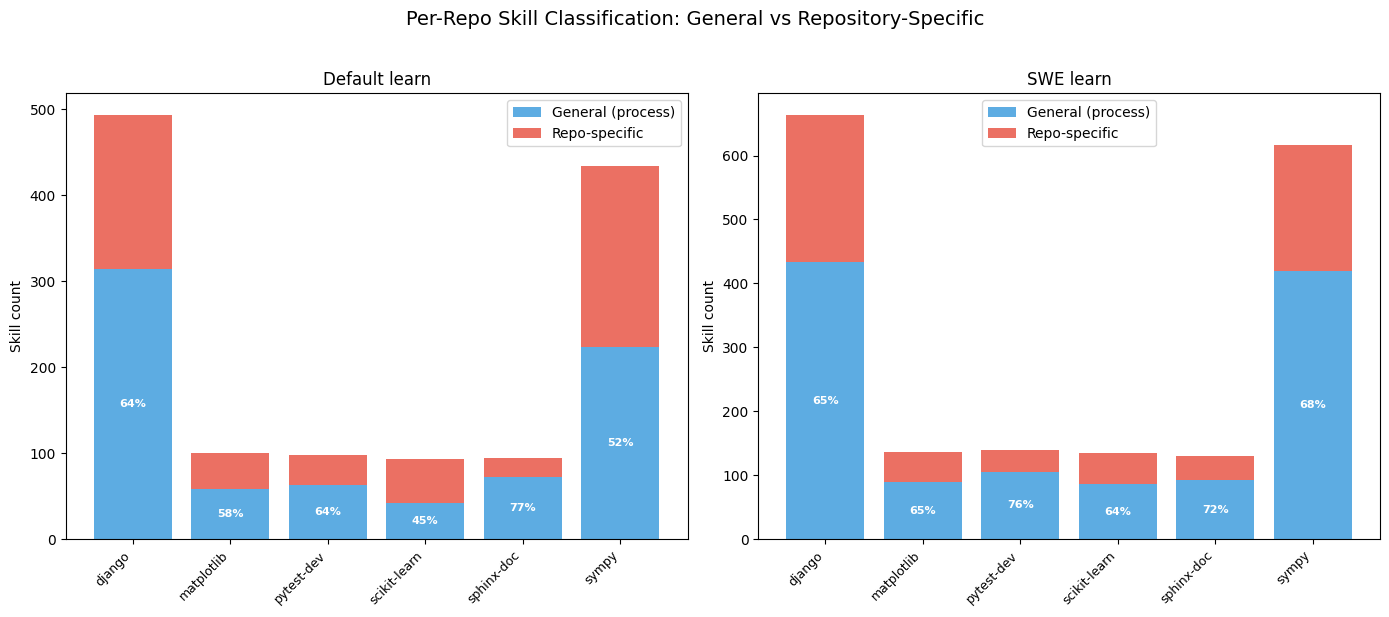


Репозиторий     | Gen Spec Gen% Ref     | Gen Spec Gen% Ref     |
                |   Default learn       |   SWE learn           |
                | G   S    %  G>  S>    | G   S    %  G>  S>    |
------------------------------------------------------------------------------------------
django          |315  179  64%   3   1    |434  230  65%  59  36    |
matplotlib      | 59   42  58%   0   0    | 89   47  65%  12   1    |
pytest-dev      | 63   35  64%   0   0    |106   34  76%   1   4    |
scikit-learn    | 42   52  45%   1   0    | 86   49  64%   1   0    |
sphinx-doc      | 73   22  77%   0   0    | 93   37  72%   1   1    |
sympy           |224  210  52%  13   5    |419  198  68%  70  99    |
------------------------------------------------------------------------------------------
TOTAL           |776  540  59%  17   6    |1227  595  67% 144 141    |

G/S — число процессных / доменных скиллов.  % — доля процессных.
G>/S> — зацитированные Gen/Spec скиллы (explicit + content) в 

In [18]:
import re

def classify_skill_specificity(content, section=''):
    """Classify a skill as 'general' or 'repo_specific'.
    
    General skills: process advice (verification, debugging, editing) without
    references to specific files, functions, classes, or domain APIs.
    Repo-specific skills: reference concrete code locations, identifiers, or
    domain-specific patterns.
    """
    text = (content + ' ' + section).lower()
    
    # --- General patterns (indicate process-level advice) ---
    general_phrases = [
        r'claiming (task |)completion without',
        r'claiming (success|inability|false)',
        r'creating test scripts? instead of',
        r'verifying git diff',
        r'verify(ing)? (the |)(changes|results|fix|removal|modification)',
        r'implement(ing)? verification steps',
        r'minimal,? targeted fixes?',
        r'avoid using sed commands? to modify',
        r'complex (file |)manipulations? with sed',
        r'multiple flawed attempts? to edit',
        r'multiple bash commands in one response',
        r'making (extensive |)(file |)modifications? without',
        r'attempting complex (file |)?manipulations?',
        r'sending multiple bash commands',
        r'identify (the |)correct problem area',
        r'test fixes? with the original',
        r'implement minimal,? targeted',
        r'precise sed pattern matching',
        r'surgical fix',
        r'access source files? before implementing',
        r'root cause analysis',
        r'proper validation of code changes',
        r'analyze file structure thoroughly',
        r'avoid false positives',
        r'do not claim (success|completion)',
        r'/testbed is (a |)writable',
        r'/testbed directory is writable',
        r'ensure no other related',
        r'confirm(ing)? (that the|execution)',
    ]
    
    # Check if this matches a general pattern
    is_general_phrase = any(re.search(p, text) for p in general_phrases)
    
    # --- Repo-specific indicators ---
    # File paths: foo/bar.py, /path/to/file.ext
    has_file_path = bool(re.search(r'[a-z_]+/[a-z_]+\.(py|js|ts|rst|txt|cfg|yaml)', text))
    # CamelCase identifiers (3+ uppercase letters in a word = class/function name)
    has_camelcase = bool(re.search(r'\b[A-Z][a-z]+[A-Z][a-z]+[A-Za-z]*\b', content))
    # Specific function/method references: func_name(), __method__
    has_func_ref = bool(re.search(r'__\w+__|\w+\(\)|\w+\.__\w+', content))
    # Domain-specific terms from each repo
    domain_terms = [
        # Django
        r'django\.(forms|core|contrib|db|template|http|urls|views|models)',
        r'(queryset|modeladmin|formfield|template_tag|urlconf)',
        # SymPy
        r'(permutation|singularityfunction|latex|_print_\w+|combinatorics)',
        # Matplotlib
        r'(figure\.py|axes3d|mpl_toolkits|backend_|canvas)',
        # pytest
        r'(assertion|_compare_eq|assertion_rewriting|byte string)',
        # scikit-learn
        r'(isolationforest|warm_start|onehotencoder|sklearn\.)',
        # Sphinx
        r'(manpage|man_pages|doctree_read|builder|sphinx/)',
    ]
    has_domain = any(re.search(p, text) for p in domain_terms)
    # Specific line numbers: "line 123", "lines 10-15"
    has_line_ref = bool(re.search(r'line\s?\d+|lines?\s?\d+-\d+', text))
    # Specific variable/parameter names in code context
    has_param_ref = bool(re.search(r'`[a-z_]+`|_[a-z]+_=|self\.[a-z_]+', content))
    
    n_specific_indicators = sum([has_file_path, has_camelcase, has_func_ref, has_domain, has_line_ref, has_param_ref])
    
    # Decision: if it matches a clear general phrase AND has no specific indicators → general
    # Otherwise, if it has 2+ specific indicators → repo_specific
    # If it has exactly 1 specific indicator but is a general phrase → general
    if is_general_phrase and n_specific_indicators <= 1:
        return 'general'
    if n_specific_indicators >= 2:
        return 'repo_specific'
    if has_file_path or has_domain:
        return 'repo_specific'
    # Single weak indicator with no general phrase match → repo_specific
    if n_specific_indicators == 1 and not is_general_phrase:
        return 'repo_specific'
    # No indicators and no general match → general (generic advice)
    if n_specific_indicators == 0:
        return 'general'
    return 'general'


def classify_skillbook_skills(skillbook_data):
    """Classify all skills in a skillbook dict. Returns (general_count, specific_count, details)."""
    skills = extract_all_skills(skillbook_data)
    general = []
    specific = []
    for s in skills:
        cls = classify_skill_specificity(s['content'], s.get('section', ''))
        if cls == 'general':
            general.append(s)
        else:
            specific.append(s)
    return general, specific


# === Analyze all per-repo skillbooks from split runs ===
split_runs_all = {
    'Default learn': 'run_20260521_034008_completed_qwen3_repos_split_default',
    'SWE learn':     'run_20260521_034013_completed_qwen3_repos_split_swe',
}

classification_results = {}

for label, dirname in split_runs_all.items():
    rd = DATA_DIR / dirname
    per_repo, _ = load_skillbooks_split(rd)
    if not per_repo:
        print(f'{label}: no per-repo skillbooks found, skipping')
        continue
    
    classification_results[label] = {}
    for repo, sb in per_repo.items():
        gen, spec = classify_skillbook_skills(sb)
        classification_results[label][repo] = {
            'total': len(gen) + len(spec),
            'general': len(gen),
            'specific': len(spec),
            'general_examples': [s['content'][:120] for s in gen[:3]],
            'specific_examples': [s['content'][:120] for s in spec[:3]],
        }

# === Print classification results ===
print('=' * 100)
print('КЛАССИФИКАЦИЯ СКИЛЛОВ: General (процессные) vs Repository-Specific (доменные)')
print('=' * 100)

for label, repos in classification_results.items():
    total_gen = sum(r['general'] for r in repos.values())
    total_spec = sum(r['specific'] for r in repos.values())
    total_all = total_gen + total_spec
    print(f'\n--- {label} ---')
    print(f'  {"Repo":<30} {"Total":>6} {"General":>8} {"Specific":>9} {"Gen%":>6}')
    print(f'  {"-" * 65}')
    for repo in sorted(repos.keys()):
        r = repos[repo]
        gen_pct = r['general'] / max(r['total'], 1)
        repo_short = repo.split('__')[0]
        print(f'  {repo_short:<30} {r["total"]:>6} {r["general"]:>8} {r["specific"]:>9} {gen_pct:>5.0%}')
    print(f'  {"TOTAL":<30} {total_all:>6} {total_gen:>8} {total_spec:>9} {total_gen/max(total_all,1):>5.0%}')

# === Stacked bar chart ===
fig, axes = plt.subplots(1, len(classification_results), figsize=(7 * len(classification_results), 6))
if len(classification_results) == 1:
    axes = [axes]

for idx, (label, repos) in enumerate(classification_results.items()):
    ax = axes[idx]
    repo_names = sorted(repos.keys())
    repo_short = [r.split('__')[0] for r in repo_names]
    general_counts = [repos[r]['general'] for r in repo_names]
    specific_counts = [repos[r]['specific'] for r in repo_names]
    
    x = np.arange(len(repo_names))
    ax.bar(x, general_counts, label='General (process)', color='#3498db', alpha=0.8)
    ax.bar(x, specific_counts, bottom=general_counts, label='Repo-specific', color='#e74c3c', alpha=0.8)
    
    # Add percentage labels
    for i, (g, s) in enumerate(zip(general_counts, specific_counts)):
        total = g + s
        if total > 0:
            pct = g / total * 100
            ax.text(i, g / 2, f'{pct:.0f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels(repo_short, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Skill count')
    ax.set_title(f'{label}')
    ax.legend()

fig.suptitle('Per-Repo Skill Classification: General vs Repository-Specific', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()











# === Сводная таблица: классификация скиллов по репозиториям + референсы ===

import json as _json
import re as _re

def find_refs_for_val_instances(bench_dir, per_repo_skillbooks):
    val_dir = bench_dir / 'trajectories' / 'val'
    repo_stats = {}
    for inst_dir in sorted(val_dir.iterdir()):
        if not inst_dir.is_dir():
            continue
        inst_id = inst_dir.name
        repo = inst_id.split('__')[0] + '__' + inst_id.split('__')[1].rsplit('-', 1)[0]
        if repo not in per_repo_skillbooks:
            continue
        sb = per_repo_skillbooks[repo]
        skills = sb.get('skills', {})
        if not skills:
            continue
        all_assistant = ''
        for tf in sorted(inst_dir.glob('iter_*.json')):
            t = _json.load(open(tf))
            for m in t.get('messages', []):
                if m['role'] == 'assistant':
                    all_assistant += ' ' + m['content']
        explicit = set(sid for sid in skills if sid in all_assistant)
        content_refs = set()
        for sid, sk in skills.items():
            if sid in explicit:
                continue
            ct = sk.get('content', '')
            clean = _re.sub(r'^(AVOID|VERIFIED|CONSIDER):\s*', '', ct)
            words = clean.split()[:5]
            if len(words) >= 4:
                phrase = ' '.join(words).lower()
                if len(phrase) > 15 and phrase in all_assistant.lower():
                    content_refs.add(sid)
        all_refs = explicit | content_refs
        if repo not in repo_stats:
            repo_stats[repo] = {'n_inst': 0, 'n_with_ref': 0,
                'expl_gen': 0, 'expl_spec': 0, 'ctn_gen': 0, 'ctn_spec': 0,
                'skills_gen': 0, 'skills_spec': 0}
            for sid, sk in skills.items():
                c = classify_skill_specificity(sk.get('content', ''), sk.get('section', ''))
                if c == 'general':
                    repo_stats[repo]['skills_gen'] += 1
                else:
                    repo_stats[repo]['skills_spec'] += 1
        rs = repo_stats[repo]
        rs['n_inst'] += 1
        if all_refs:
            rs['n_with_ref'] += 1
        for sid in explicit:
            c = classify_skill_specificity(skills[sid]['content'], skills[sid].get('section', ''))
            if c == 'general':
                rs['expl_gen'] += 1
            else:
                rs['expl_spec'] += 1
        for sid in content_refs:
            c = classify_skill_specificity(skills[sid]['content'], skills[sid].get('section', ''))
            if c == 'general':
                rs['ctn_gen'] += 1
            else:
                rs['ctn_spec'] += 1
    return repo_stats

table_runs = [
    ('Default learn', 'run_20260521_034008_completed_qwen3_repos_split_default'),
    ('SWE learn',     'run_20260521_034013_completed_qwen3_repos_split_swe'),
]

all_data = {}
run_labels = []
for run_label, dirname in table_runs:
    rd = DATA_DIR / dirname
    bench = next(d for d in rd.iterdir() if d.is_dir() and 'SWE-bench' in d.name)
    per_repo = {}
    for repo_dir in (bench / 'skillbooks' / 'per_repo').iterdir():
        fp = repo_dir / 'final_skillbook.json'
        if fp.exists():
            per_repo[repo_dir.name] = _json.load(open(fp))
    ref_stats = find_refs_for_val_instances(bench, per_repo)

    run_data = {}
    for repo, sb in per_repo.items():
        gen, spec = classify_skillbook_skills(sb)
        rf = ref_stats.get(repo, {})
        run_data[repo] = {
            'gen': len(gen), 'spec': len(spec),
            'ref_gen': rf.get('expl_gen', 0) + rf.get('ctn_gen', 0),
            'ref_spec': rf.get('expl_spec', 0) + rf.get('ctn_spec', 0),
        }
    all_data[run_label] = run_data
    run_labels.append(run_label)

all_repos = sorted(set(r for rd in all_data.values() for r in rd))

print()
print(f'{"Репозиторий":<16}| Gen Spec Gen% Ref     | Gen Spec Gen% Ref     |')
print(f'{"":16}|   Default learn       |   SWE learn           |')
print(f'{"":16}| G   S    %  G>  S>    | G   S    %  G>  S>    |')
print('-' * 90)

for repo in all_repos:
    short = repo.split('__')[0]
    row = f'{short:<16}'
    for rl in run_labels:
        r = all_data.get(rl, {}).get(repo, None)
        if r:
            total = r['gen'] + r['spec']
            gp = r['gen'] / max(total, 1)
            row += f'|{r["gen"]:>3} {r["spec"]:>4} {gp:>4.0%} {r["ref_gen"]:>3} {r["ref_spec"]:>3}    '
        else:
            row += f'| —   —    —   —   —     '
    print(row + '|')

print('-' * 90)
row = f'{"TOTAL":<16}'
for rl in run_labels:
    rd_data = all_data.get(rl, {})
    g = sum(r['gen'] for r in rd_data.values())
    s = sum(r['spec'] for r in rd_data.values())
    t = g + s
    gp = g / max(t, 1)
    rg = sum(r['ref_gen'] for r in rd_data.values())
    rs = sum(r['ref_spec'] for r in rd_data.values())
    row += f'|{g:>3} {s:>4} {gp:>4.0%} {rg:>3} {rs:>3}    '
print(row + '|')

print()
print('G/S — число процессных / доменных скиллов.  % — доля процессных.')
print('G>/S> — зацитированные Gen/Spec скиллы (explicit + content) в val траекториях.')

# === Show representative examples ===
print('\n=== Примеры скиллов по типам (repos-swe #24) ===')
label = 'SWE learn'
if label in classification_results:
    for repo in sorted(classification_results[label].keys())[:3]:
        r = classification_results[label][repo]
        repo_short = repo.split('__')[0]
        print(f'\n  {repo_short} ({r["general"]} general, {r["specific"]} specific):')
        print(f'    General examples:')
        for ex in r['general_examples']:
            print(f'      - {ex}')
        print(f'    Specific examples:')
        for ex in r['specific_examples']:
            print(f'      - {ex}')

**Интерпретация:** Классификация показывает, что в SWE-режиме (repos-swe) доля general-скиллов значительно выше, чем в Default, из-за обилия AVOID-паттернов вроде "не заявляй об успехе без верификации". Default-режим порождает больше repo-specific скиллов — абстрактные советы обычно содержат конкретные имена классов и функций. Django выделяется наибольшим числом скиллов обоих типов. Repo-specific скиллы составляют основную ценность скиллбука: они переносят знания между инстансами одного репозитория. General-скиллы потенциально переносимы между репозиториями, но их ценность зависит от того, использует ли их агент при будущих запусках.

## 14. Ablation: только general-скиллы (без repository-specific)

**Методология:** Удаляем из каждого per-repo скиллбука все repo-specific скиллы, оставляя только general (процессные). Для каждого репозитория сравниваем:
1. Оригинальный скиллбук vs "general-only" скиллбук — размер и содержание
2. Эмбеддинг-симилярность general-скиллов между репозиториями — показываем, насколько general-скиллы пересекаются между разными репозиториями (т.е. действительно ли они универсальны)
3. Heatmap попарной косинусной симилярности между general-only скиллбуками разных репозиториев

Это отвечает на вопрос: если бы мы использовали только general-скиллы (переносимые между репозиториями), насколько они были бы информативны и уникальны?

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

# Build general-only skillbooks for each split run
ablation_results = {}

for label, dirname in split_runs_all.items():
    rd = DATA_DIR / dirname
    per_repo, _ = load_skillbooks_split(rd)
    if not per_repo:
        continue
    
    ablation_results[label] = {}
    for repo, sb in per_repo.items():
        gen, spec = classify_skillbook_skills(sb)
        ablation_results[label][repo] = {
            'original_count': len(gen) + len(spec),
            'general_count': len(gen),
            'specific_count': len(spec),
            'general_skills': gen,
            'specific_skills': spec,
        }

# === 1. Comparison table: original vs general-only ===
print('=' * 110)
print('ABLATION: General-only скиллбуки (без repo-specific)')
print('=' * 110)

for label, repos in ablation_results.items():
    print(f'\n--- {label} ---')
    print(f'  {"Repo":<30} {"Original":>9} {"General":>8} {"Specific":>9} {"Gen%":>6} {"Lost%":>6}')
    print(f'  {"-" * 75}')
    totals = {'orig': 0, 'gen': 0, 'spec': 0}
    for repo in sorted(repos.keys()):
        r = repos[repo]
        repo_short = repo.split('__')[0]
        gen_pct = r['general_count'] / max(r['original_count'], 1)
        lost_pct = r['specific_count'] / max(r['original_count'], 1)
        totals['orig'] += r['original_count']
        totals['gen'] += r['general_count']
        totals['spec'] += r['specific_count']
        print(f'  {repo_short:<30} {r["original_count"]:>9} {r["general_count"]:>8} {r["specific_count"]:>9} {gen_pct:>5.0%} {lost_pct:>5.0%}')
    print(f'  {"TOTAL":<30} {totals["orig"]:>9} {totals["gen"]:>8} {totals["spec"]:>9} '
          f'{totals["gen"]/max(totals["orig"],1):>5.0%} {totals["spec"]/max(totals["orig"],1):>5.0%}')


# === 2. Cross-repo general skill similarity (SWE run #24) ===
print('\n\n=== Cross-Repo General Skill Similarity (#24 repos-swe) ===')

target_label = '#24 repos-swe'
if target_label in ablation_results:
    repos = ablation_results[target_label]
    repo_names = sorted(repos.keys())
    repo_short = [r.split('__')[0] for r in repo_names]
    
    # Compute centroid embeddings for general-only skillbooks
    general_contents = {}
    general_embeddings = {}
    for repo in repo_names:
        gen_skills = repos[repo]['general_skills']
        if gen_skills:
            contents = [s['content'] for s in gen_skills]
            general_contents[repo] = contents
            embs = emb_model.encode(contents, show_progress_bar=False, normalize_embeddings=True)
            general_embeddings[repo] = embs
    
    # Pairwise cosine similarity between repo centroids
    n = len(repo_names)
    sim_matrix = np.zeros((n, n))
    for i, r1 in enumerate(repo_names):
        for j, r2 in enumerate(repo_names):
            if r1 in general_embeddings and r2 in general_embeddings:
                centroid1 = general_embeddings[r1].mean(axis=0, keepdims=True)
                centroid2 = general_embeddings[r2].mean(axis=0, keepdims=True)
                sim_matrix[i, j] = cosine_similarity(centroid1, centroid2)[0, 0]
    
    print(f'\nCentroid cosine similarity (general skills):')
    header = f'  {"":<22}' + ''.join(f'{s[:10]:>12}' for s in repo_short)
    print(header)
    for i, r1 in enumerate(repo_short):
        row = f'  {r1:<22}' + ''.join(f'{sim_matrix[i,j]:>12.3f}' for j in range(n))
        print(row)
    
    # === 3. Heatmap ===
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Heatmap: centroid similarity
    im = ax1.imshow(sim_matrix, cmap='YlOrRd', vmin=0.5, vmax=1.0)
    ax1.set_xticks(range(n))
    ax1.set_yticks(range(n))
    ax1.set_xticklabels(repo_short, rotation=45, ha='right', fontsize=9)
    ax1.set_yticklabels(repo_short, fontsize=9)
    ax1.set_title(f'General-Only Skill Similarity\n(Centroid Cosine Sim)')
    for i in range(n):
        for j in range(n):
            ax1.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=ax1, shrink=0.8)
    
    # Heatmap: also for Default run (#23)
    target_label_default = '#23 repos-default'
    if target_label_default in ablation_results:
        repos_d = ablation_results[target_label_default]
        repo_names_d = sorted(repos_d.keys())
        repo_short_d = [r.split('__')[0] for r in repo_names_d]
        
        general_embeddings_d = {}
        for repo in repo_names_d:
            gen_skills = repos_d[repo]['general_skills']
            if gen_skills:
                contents = [s['content'] for s in gen_skills]
                embs = emb_model.encode(contents, show_progress_bar=False, normalize_embeddings=True)
                general_embeddings_d[repo] = embs
        
        n_d = len(repo_names_d)
        sim_matrix_d = np.zeros((n_d, n_d))
        for i, r1 in enumerate(repo_names_d):
            for j, r2 in enumerate(repo_names_d):
                if r1 in general_embeddings_d and r2 in general_embeddings_d:
                    c1 = general_embeddings_d[r1].mean(axis=0, keepdims=True)
                    c2 = general_embeddings_d[r2].mean(axis=0, keepdims=True)
                    sim_matrix_d[i, j] = cosine_similarity(c1, c2)[0, 0]
        
        im2 = ax2.imshow(sim_matrix_d, cmap='YlOrRd', vmin=0.5, vmax=1.0)
        ax2.set_xticks(range(n_d))
        ax2.set_yticks(range(n_d))
        ax2.set_xticklabels(repo_short_d, rotation=45, ha='right', fontsize=9)
        ax2.set_yticklabels(repo_short_d, fontsize=9)
        ax2.set_title(f'General-Only Skill Similarity\n(Default, Centroid Cosine Sim)')
        for i in range(n_d):
            for j in range(n_d):
                ax2.text(j, i, f'{sim_matrix_d[i,j]:.2f}', ha='center', va='center', fontsize=8)
        fig.colorbar(im2, ax=ax2, shrink=0.8)
    
    plt.tight_layout()
    plt.show()
    
    # === 4. Within-repo redundancy of general skills ===
    print('\n=== Redundancy within General-Only Skillbooks ===')
    print(f'  {"Repo":<30} {"N general":>10} {"Redundant%":>11} {"Avg Max Sim":>11} {"Top repeated theme"}')
    print(f'  {"-" * 80}')
    
    for label, repos in ablation_results.items():
        for repo in sorted(repos.keys()):
            gen_skills = repos[repo]['general_skills']
            if len(gen_skills) < 2:
                continue
            repo_short = repo.split('__')[0]
            contents = [s['content'] for s in gen_skills]
            embs = emb_model.encode(contents, show_progress_bar=False, normalize_embeddings=True)
            sim = cosine_similarity(embs)
            np.fill_diagonal(sim, 0)
            
            red_pct = sum(1 for i in range(len(contents)) if sim[i].max() >= 0.85) / len(contents)
            avg_sim = sim.max(axis=1).mean()
            
            # Find most common general theme (highest average similarity)
            avg_sims = sim.mean(axis=1)
            top_idx = avg_sims.argmax()
            top_theme = contents[top_idx][:60]
            
            print(f'  {repo_short:<30} {len(gen_skills):>10} {red_pct:>10.0%} {avg_sim:>11.3f} {top_theme}')


# === 5. Detailed comparison: what's lost in ablation ===
print('\n\n=== Ablation Impact: что теряется при удалении repo-specific скиллов ===')
target = '#24 repos-swe'
if target in ablation_results:
    for repo in sorted(ablation_results[target].keys())[:3]:
        r = ablation_results[target][repo]
        repo_short = repo.split('__')[0]
        print(f'\n  {repo_short}:')
        print(f'    General ({r["general_count"]} retained):')
        for s in r['general_skills'][:3]:
            print(f'      - {s["content"][:110]}')
        print(f'    Specific ({r["specific_count"]} removed):')
        for s in r['specific_skills'][:3]:
            print(f'      - {s["content"][:110]}')

ABLATION: General-only скиллбуки (без repo-specific)

--- Default learn ---
  Repo                            Original  General  Specific   Gen%  Lost%
  ---------------------------------------------------------------------------
  django                               494      315       179   64%   36%
  matplotlib                           101       59        42   58%   42%
  pytest-dev                            98       63        35   64%   36%
  scikit-learn                          94       42        52   45%   55%
  sphinx-doc                            95       73        22   77%   23%
  sympy                                434      224       210   52%   48%
  TOTAL                               1316      776       540   59%   41%

--- SWE learn ---
  Repo                            Original  General  Specific   Gen%  Lost%
  ---------------------------------------------------------------------------
  django                               664      434       230   65%   35%
  mat

**Интерпретация:** Ablation-анализ показывает, что при удалении repo-specific скиллов теряется существенная доля скиллбука (30-70% в зависимости от репозитория и режима). Cross-repo симилярность general-скиллов высока (centroid cosine sim > 0.85 между большинством пар репозиториев), что подтверждает их действительно универсальный характер — одни и те же процессные советы повторяются во всех репозиториях. Это означает, что general-скиллы можно без потерь объединить в один глобальный набор вместо дублирования в каждом per-repo скиллбуке. Основная ценность per-repo скиллбуков — в repo-specific скиллах, которые не переносимы. Практический вывод: оптимальная стратегия — глобальный general-скиллбук + per-repo specific-скиллбук, вместо полного per-repo дублирования.

## 15. Итоговые выводы

In [20]:
print("""
КЛЮЧЕВЫЕ ВЫВОДЫ:
================

1. SWE vs Default обучение:
   - SWE: 35-47% AVOID, 0% PLAIN — структурированные негативные ограничения
   - Default: 100% PLAIN-проза — позитивные советы
   - SWE генерирует в 2 раза больше скиллов (14.5k vs 6.9k для qwen3-6a)
   - Скиллы SWE на ~30% короче (87-99 vs 116-144 символов)

2. Рост скиллбука:
   - Линейное накопление, без насыщения (в среднем 21 скилл/инстанс на итерации 5 для SWE)
   - SWE растёт в 2 раза быстрее Default на каждой итерации
   - GLM растёт медленнее всех (меньше неудач → меньше материала для обучения)

3. Кросс-инстанс избыточность (критическая проблема):
   - Per-instance: 92-96% скиллов — близкие дубликаты (sim >= 0.85)
   - Split Default: 4.2% избыточности — значительно лучше
   - Split SWE: 31.6% — AVOID-префиксные скиллы кластеризуются вместе
   - Дедупликация необходима для всех shared-режимов скиллбука

4. Использование скиллов агентом:
   - Скиллы SWE упоминаются в 27% случаев vs 18-24% для Default
   - 65% инстансов SWE содержат хотя бы одну ссылку vs 22% для Default
   - Структурированные префиксы (AVOID/VERIFIED) более распознаваемы для агента

5. Влияние на решение:
   - SWE помогает через мета-когнитивные скиллы (верификация, осведомлённость о среде)
   - Default помогает через доменно-специфичные знания (паттерны django, sympy)
   - У GLM всего 2 скиллбук-ассистированных инстанса (высокий базовый процент не оставляет пространства)

6. Per-repo vs Global:
   - Per-repo скиллбуки: от 95 (scikit-learn) до 664 (django) скиллов
   - Глобальный скиллбук (661 скилл) страдает от универсальных кросс-репо советов
   - Per-repo дедупликация держит избыточность на низком уровне (4-32%)
   - Per-instance без дедупликации → 95%+ избыточности между инстансами

7. Сравнение моделей:
   - GLM-4.5-flash: лучший процент решения (35-38%), меньше всего скиллов, наименьшее обучение
   - Qwen3-Next: 40% решения, умеренное число скиллов
   - Qwen3-Coder-30B: 21-27% решения, наиболее продуктивный «обучающийся»
   - Режим обучения (SWE vs Default) важнее выбора модели
""")


КЛЮЧЕВЫЕ ВЫВОДЫ:

1. SWE vs Default обучение:
   - SWE: 35-47% AVOID, 0% PLAIN — структурированные негативные ограничения
   - Default: 100% PLAIN-проза — позитивные советы
   - SWE генерирует в 2 раза больше скиллов (14.5k vs 6.9k для qwen3-6a)
   - Скиллы SWE на ~30% короче (87-99 vs 116-144 символов)

2. Рост скиллбука:
   - Линейное накопление, без насыщения (в среднем 21 скилл/инстанс на итерации 5 для SWE)
   - SWE растёт в 2 раза быстрее Default на каждой итерации
   - GLM растёт медленнее всех (меньше неудач → меньше материала для обучения)

3. Кросс-инстанс избыточность (критическая проблема):
   - Per-instance: 92-96% скиллов — близкие дубликаты (sim >= 0.85)
   - Split Default: 4.2% избыточности — значительно лучше
   - Split SWE: 31.6% — AVOID-префиксные скиллы кластеризуются вместе
   - Дедупликация необходима для всех shared-режимов скиллбука

4. Использование скиллов агентом:
   - Скиллы SWE упоминаются в 27% случаев vs 18-24% для Default
   - 65% инстансов SWE содержат